In [1]:
from pathlib import Path
import re, gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# -------------------- constants --------------------
DATASET = "Dip146"
MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DEFAULT_DTYPE = "float64"

EV_TO_KCAL = 23.06054783
HARTREE_TO_KCAL = 627.50947406
AU_TO_DEBYE = 2.541746

# Explicit Dip146 finite-difference step used by GSCDB qchem_inputs / analyze.ipynb
DIP146_STEP_AU = 0.0001

# Convert field from atomic units to V/Å before giving it to MACE-POLAR
FIELD_AU_TO_VA = 51.4220674763

# GSCDB/analyze convention: no extra minus sign.
# dipole(D) = reaction_energy(kcal/mol) / 627.50947406 / (2*0.0001) * 2.541746
KCAL_TO_DEBYE = AU_TO_DEBYE / (2 * DIP146_STEP_AU * HARTREE_TO_KCAL)

# -------------------- paths --------------------
def find_root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from the GSCDB root folder or from GSCDB/Analysis.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / "Molecule_Energies_MACE_POLAR_Dip146_ALL3_CORRECTED.csv"
rxn_out = A / "Reaction_Energies_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv"
val_out = A / "Results_values_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv"
err_out = A / "Results_errors_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv"
met_out = A / "Dip146_ALL3_CORRECTED_metrics.csv"
log_out = A / "Molecule_Energies_MACE_POLAR_Dip146_ALL3_CORRECTED_error_log.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("Dip146 step size, a.u.:", DIP146_STEP_AU)
print("kcal/mol to Debye scale:", KCAL_TO_DEBYE)

# -------------------- helpers --------------------
def reset_calc(calc):
    for attr, val in [("results", {}), ("atoms", None)]:
        try:
            setattr(calc, attr, val)
        except Exception:
            pass
    try:
        calc.reset()
    except Exception:
        pass

def parse_field_text(text):
    d = {"X": 0.0, "Y": 0.0, "Z": 0.0}
    # Handles X 0.0001, X: 0.0001, 'X': 0.0001, 'X': np.float64(0.0001)
    pat = r"['\"]?([XYZxyz])['\"]?\s*[:=]?\s*(?:np\.float64\()?([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    for ax, num in re.findall(pat, str(text)):
        d[ax.upper()] = float(num)
    return np.array([d["X"], d["Y"], d["Z"]], float)

def read_qchem(qfile):
    charge, mult = 0, 1
    field = np.zeros(3)
    if not qfile.exists():
        return charge, mult, field

    lines = qfile.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        s = line.strip().lower()

        if s == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                parts = lines[j].split()
                if len(parts) >= 2:
                    charge, mult = int(float(parts[0])), int(float(parts[1]))

        if s == "$multipole_field":
            block = []
            j = i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                block.append(lines[j])
                j += 1
            field = parse_field_text(" ".join(block))

    return charge, mult, field

def read_xyz_raw_field(xfile):
    try:
        lines = xfile.read_text(errors="ignore").splitlines()
        return parse_field_text(" ".join(lines[:3]))
    except Exception:
        return np.zeros(3)

def suffix_field(mol):
    if mol.endswith("+"):
        return np.array([0.0, 0.0, DIP146_STEP_AU])
    if mol.endswith("-"):
        return np.array([0.0, 0.0, -DIP146_STEP_AU])
    return np.zeros(3)

def prepare_atoms(mol):
    xfile, qfile = X / f"{mol}.xyz", Q / f"{mol}.in"
    charge, mult, field_au = read_qchem(qfile)
    atoms = read(xfile)

    charge = int(float(atoms.info.get("charge", charge)))
    mult = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", mult))))

    if np.allclose(field_au, 0):
        field_au = parse_field_text(atoms.info.get("multipole_field", atoms.info.get("external_field", "")))
    if np.allclose(field_au, 0):
        field_au = read_xyz_raw_field(xfile)
    if np.allclose(field_au, 0):
        field_au = suffix_field(mol)

    atoms.positions -= atoms.positions.mean(axis=0)
    atoms.info["charge"] = charge
    atoms.info["spin"] = mult
    atoms.info["external_field"] = field_au * FIELD_AU_TO_VA

    return atoms, charge, mult, field_au

def mols_from_stoich(st):
    p = [x.strip() for x in str(st).split(",")]
    return p[1::2]

def rxn_energy(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e = 0.0
    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]
        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan
        e += coef * float(df_mol.loc[mol, col])
    return e * EV_TO_KCAL

def metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x, y = d["x"].to_numpy(float), d["y"].to_numpy(float)
    err = y - x
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    return len(x), np.sqrt(np.mean(err**2)), np.mean(np.abs(err)), r

# -------------------- load GSCDB --------------------
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_rxn_base = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_base = pd.read_csv(A / "Results_values.csv", index_col=0)

dip_eval = df_eval[df_eval["Dataset"] == DATASET].copy()
idx = dip_eval.index
rxn_base = df_rxn_base.loc[idx].copy()
val_base = df_val_base.loc[idx].copy()

print("\nDip146 rows:", len(dip_eval))
print("Existing wB97M-V MAE in Results_values.csv:",
      np.mean(np.abs(val_base["wB97M-V"] - val_base["Reference"])))

# Validate explicit conversion against GSCDB wB97M-V
test_conv = rxn_base["wB97M-V"] * KCAL_TO_DEBYE
print("Max |explicit conversion - GSCDB wB97M-V|:",
      np.nanmax(np.abs(test_conv - val_base["wB97M-V"])))

molecules = sorted({m for st in dip_eval["Stoichiometry"] for m in mols_from_stoich(st)})
print("Unique Dip146 molecules:", len(molecules))

# -------------------- metadata + field check --------------------
meta = []
for mol in molecules:
    atoms, ch, mult, f = prepare_atoms(mol)
    meta.append({
        "Molecule": mol, "charge": ch, "multiplicity": mult, "num_atoms": len(atoms),
        "field_au_x": f[0], "field_au_y": f[1], "field_au_z": f[2],
        "field_VA_x": f[0] * FIELD_AU_TO_VA,
        "field_VA_y": f[1] * FIELD_AU_TO_VA,
        "field_VA_z": f[2] * FIELD_AU_TO_VA,
    })

df_mol = pd.DataFrame(meta).set_index("Molecule")
print("\nField value counts:")
print(df_mol[["field_au_x", "field_au_y", "field_au_z"]].value_counts().head(20))

if np.allclose(df_mol[["field_au_x", "field_au_y", "field_au_z"]].to_numpy(), 0):
    raise ValueError("All external fields are zero. Stop: field parsing failed.")

# -------------------- MACE-POLAR molecule energies --------------------
error_log = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DEFAULT_DTYPE)
    df_mol[col] = np.nan

    for n, mol in enumerate(tqdm(molecules, desc=col), start=1):
        try:
            atoms, ch, mult, f = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc
            df_mol.loc[mol, col] = float(atoms.get_potential_energy())
        except Exception as exc:
            error_log.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % 10 == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(error_log).to_csv(log_out, index=False)
df_mol.to_csv(mol_out)

print("\nSaved molecule energies:", mol_out)
print("Missing energies:")
print(df_mol[list(MODELS)].isna().sum())

# -------------------- reaction energies --------------------
df_rxn = rxn_base.copy()
for rid, row in tqdm(dip_eval.iterrows(), total=len(dip_eval), desc="Reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy zero/unique check:")
for col in MODELS:
    print(col, "| exact zeros:", np.isclose(df_rxn[col], 0).sum(),
          "| unique:", df_rxn[col].nunique(),
          "| min/max:", df_rxn[col].min(), df_rxn[col].max())

# -------------------- convert to Debye with explicit step size --------------------
df_val = val_base.copy()
for col in MODELS:
    df_val[col] = df_rxn[col] * KCAL_TO_DEBYE

df_val.to_csv(val_out)

df_err = df_val.copy()
for col in df_val.columns:
    if col not in ["Dataset", "Reaction", "Reference"]:
        df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - df_val["Reference"]
df_err.to_csv(err_out)

# -------------------- metrics --------------------
rows = []
for col in ["wB97M-V", *MODELS.keys()]:
    n, rmse, mae, r = metrics(df_val["Reference"], df_val[col])
    rows.append({"Dataset": DATASET, "Model": col, "Unit": "D", "N": n,
                 "RMSE": rmse, "MAE": mae, "Pearson_r": r})

df_met = pd.DataFrame(rows)
df_met.to_csv(met_out, index=False)

print("\nMetric table:")
print(df_met)

print("\nSaved files:")
print(mol_out)
print(rxn_out)
print(val_out)
print(err_out)
print(met_out)
print(log_out)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: c:\Users\91988\GSCDB Benchmarking
DEVICE: cpu
Dip146 step size, a.u.: 0.0001
kcal/mol to Debye scale: 20.2526503986852

Dip146 rows: 190
Existing wB97M-V MAE in Results_values.csv: 0.05797089865832518
Max |explicit conversion - GSCDB wB97M-V|: 8.881784197001252e-16
Unique Dip146 molecules: 380

Field value counts:
field_au_x  field_au_y  field_au_z
 0.0000      0.0000      0.0001       114
                        -0.0001       114
 0.0001      0.0000      0.0000        42
-0.0001      0.0000      0.0000        42
 0.0000      0.0001      0.0000        34
            -0.0001      0.0000        34
Name: count, dtype: int64

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 380/380 [01:35<00:00,  3.98it/s]



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-m: 100%|██████████| 380/380 [02:58<00:00,  2.13it/s]



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-l: 100%|██████████| 380/380 [07:12<00:00,  1.14s/it]



Saved molecule energies: c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_ALL3_CORRECTED.csv
Missing energies:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Reaction energies: 100%|██████████| 190/190 [00:00<00:00, 783.69it/s]



Reaction-energy zero/unique check:
mace-polar-1-s | exact zeros: 0 | unique: 190 | min/max: -0.3817894645609882 0.26321820016634384
mace-polar-1-m | exact zeros: 0 | unique: 190 | min/max: -0.4525954654728762 0.3309810623811256
mace-polar-1-l | exact zeros: 0 | unique: 190 | min/max: -0.4445448382323571 0.3318787685958897

Metric table:
  Dataset           Model Unit    N      RMSE       MAE  Pearson_r
0  Dip146         wB97M-V    D  190  0.109842  0.057971   0.999008
1  Dip146  mace-polar-1-s    D  190  0.714442  0.524133   0.965657
2  Dip146  mace-polar-1-m    D  190  0.333479  0.196818   0.991056
3  Dip146  mace-polar-1-l    D  190  0.300921  0.173650   0.992516

Saved files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_ALL3_CORRECTED.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv
c:\Users\9

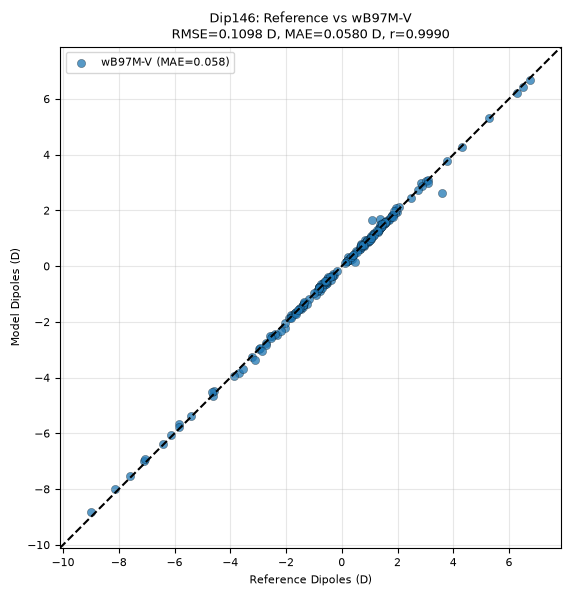

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_wB97M-V.png


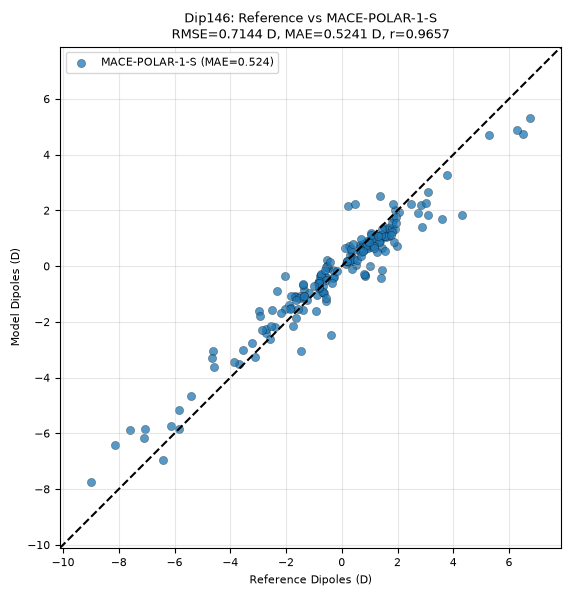

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-s.png


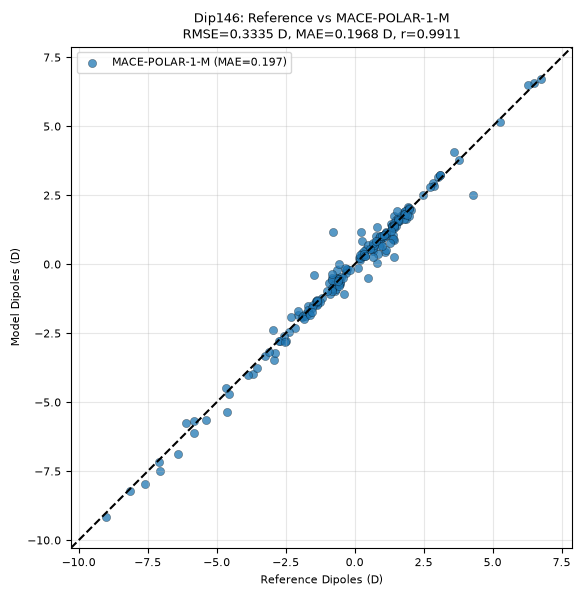

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-m.png


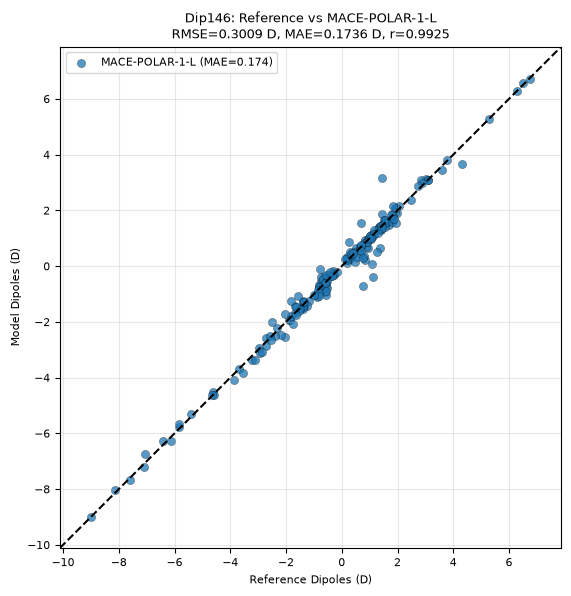

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-l.png


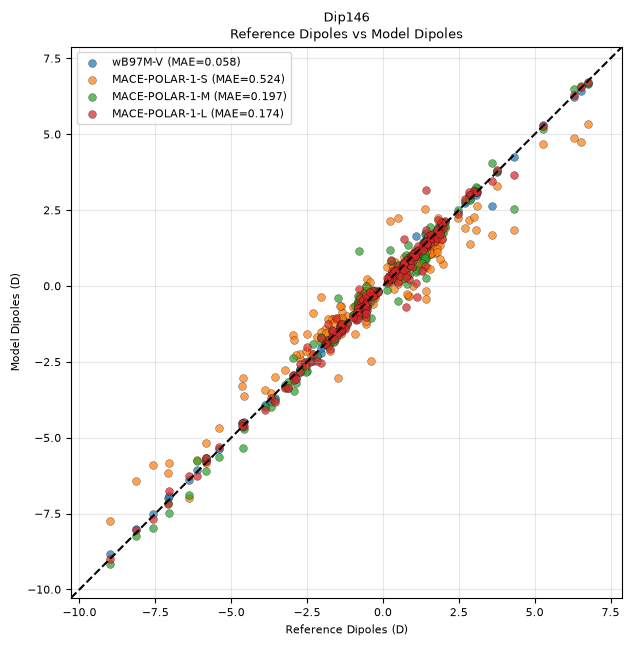

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Figure12_style_Reference_vs_all_models.png


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

DATASET = "Dip146"
UNIT = "D"

val_file = A / "Results_values_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv"
df = pd.read_csv(val_file, index_col=0)

models = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
labels = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

def metric(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x, y = d["x"].to_numpy(float), d["y"].to_numpy(float)
    e = y - x
    return len(x), np.sqrt(np.mean(e**2)), np.mean(np.abs(e)), np.corrcoef(x, y)[0, 1]

def limits(*cols):
    v = np.concatenate([pd.to_numeric(c, errors="coerce").dropna().to_numpy(float) for c in cols])
    pad = 0.07 * (v.max() - v.min())
    return v.min() - pad, v.max() + pad

# ------------------------------------------------------------
# 1. Individual correlation plots
# ------------------------------------------------------------
for m in models:
    x, y = df["Reference"], df[m]
    n, rmse, mae, r = metric(x, y)
    lo, hi = limits(x, y)

    plt.figure(figsize=(6.5, 6))
    plt.scatter(x, y, s=35, alpha=0.75, edgecolors="black", linewidths=0.25,
                label=f"{labels[m]} (MAE={mae:.3f})")
    plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel(f"Reference Dipoles ({UNIT})")
    plt.ylabel(f"Model Dipoles ({UNIT})")
    plt.title(f"{DATASET}: Reference vs {labels[m]}\nRMSE={rmse:.4f} {UNIT}, MAE={mae:.4f} {UNIT}, r={r:.4f}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out = FIG / f"{DATASET}_Reference_vs_{m}.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)

# ------------------------------------------------------------
# 2. Extra Figure-12-style plot:
#    Reference Dipoles vs wB97M-V + MACE-POLAR S/M/L
# ------------------------------------------------------------
lo, hi = limits(df["Reference"], *[df[m] for m in models])

plt.figure(figsize=(7, 6.5))

for m in models:
    n, rmse, mae, r = metric(df["Reference"], df[m])
    plt.scatter(df["Reference"], df[m], s=32, alpha=0.72, linewidths=0.25,
                edgecolors="black", label=f"{labels[m]} (MAE={mae:.3f})")

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Reference Dipoles (D)")
plt.ylabel("Model Dipoles (D)")
plt.title("Dataset: Dip146\nReference Dipoles (D) vs Model Dipoles (D)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

out = FIG / "Dip146_Figure12_style_Reference_vs_all_models.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

In [5]:
from pathlib import Path
import re, gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

DATASET = "HR46"
MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DEFAULT_DTYPE = "float64"

EV_TO_KCAL = 23.06054783
HARTREE_TO_KCAL = 627.50947406
BOHR_TO_ANG = 0.529177

HR46_STEP_AU = 0.004
FIELD_AU_TO_VA = 51.4220674763

KCAL_TO_ANG3 = (BOHR_TO_ANG ** 3) / (HARTREE_TO_KCAL * HR46_STEP_AU ** 2)

def find_root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from the GSCDB root folder or from GSCDB/Analysis.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / "Molecule_Energies_MACE_POLAR_HR46_ALL3_FIXED_V2.csv"
rxn_out = A / "Reaction_Energies_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv"
val_out = A / "Results_values_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv"
err_out = A / "Results_errors_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv"
met_out = A / "HR46_ALL3_FIXED_V2_metrics.csv"
log_out = A / "Molecule_Energies_MACE_POLAR_HR46_ALL3_FIXED_V2_error_log.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("HR46_STEP_AU:", HR46_STEP_AU)
print("KCAL_TO_ANG3:", KCAL_TO_ANG3)

def reset_calc(calc):
    try:
        calc.reset()
    except Exception:
        pass
    try:
        calc.results = {}
    except Exception:
        pass
    try:
        calc.atoms = None
    except Exception:
        pass

def read_qchem(qfile):
    charge, mult, field = 0, 1, np.zeros(3)

    if not qfile.exists():
        return charge, mult, field

    lines = qfile.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        s = line.strip().lower()

        if s == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, mult = int(float(p[0])), int(float(p[1]))

        if s == "$multipole_field":
            d = {"X": 0.0, "Y": 0.0, "Z": 0.0}
            j = i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                p = lines[j].split()
                if len(p) == 2 and p[0].upper() in d:
                    d[p[0].upper()] = float(p[1])
                j += 1
            field = np.array([d["X"], d["Y"], d["Z"]], float)

    return charge, mult, field

def parse_field_metadata(value):
    if value is None:
        return np.zeros(3)

    if isinstance(value, dict):
        return np.array([
            float(value.get("X", value.get("x", 0.0))),
            float(value.get("Y", value.get("y", 0.0))),
            float(value.get("Z", value.get("z", 0.0))),
        ])

    text = str(value)
    d = {"X": 0.0, "Y": 0.0, "Z": 0.0}

    for ax, num in re.findall(r"['\"]?([XYZxyz])['\"]?\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", text):
        d[ax.upper()] = float(num)

    return np.array([d["X"], d["Y"], d["Z"]], float)

def field_from_suffix(mol):
    m = re.search(r"([012])([+-])$", mol)

    if not m:
        return np.zeros(3)

    field = np.zeros(3)
    axis = int(m.group(1))
    sign = 1.0 if m.group(2) == "+" else -1.0
    field[axis] = sign * HR46_STEP_AU

    return field

def prepare_atoms(mol):
    xfile = X / f"{mol}.xyz"
    qfile = Q / f"{mol}.in"

    charge, mult, field_au = read_qchem(qfile)
    atoms = read(xfile)

    charge = int(float(atoms.info.get("charge", charge)))
    mult = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", mult))))

    if np.allclose(field_au, 0.0) and re.search(r"[012][+-]$", mol):
        if "multipole_field" in atoms.info:
            field_au = parse_field_metadata(atoms.info["multipole_field"])
        elif "external_field" in atoms.info:
            field_au = parse_field_metadata(atoms.info["external_field"])

    if np.allclose(field_au, 0.0):
        field_au = field_from_suffix(mol)

    atoms.positions -= atoms.positions.mean(axis=0)
    atoms.info["charge"] = charge
    atoms.info["spin"] = mult
    atoms.info["external_field"] = field_au * FIELD_AU_TO_VA

    return atoms, charge, mult, field_au

def mols_from_stoich(st):
    p = [x.strip() for x in str(st).split(",")]
    return p[1::2]

def reaction_energy(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e_ev = 0.0

    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, col])

    return e_ev * EV_TO_KCAL

def metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x, y = d["x"].to_numpy(float), d["y"].to_numpy(float)
    err = y - x

    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(err ** 2)),
        "MAE": np.mean(np.abs(err)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_rxn_base_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_base_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_info = pd.read_csv(I / "Datasets.csv", index_col=0)

ev = df_eval[df_eval["Dataset"] == DATASET].copy()
idx = ev.index

rxn_base = df_rxn_base_all.loc[idx].copy()
val_base = df_val_base_all.loc[idx].copy()

datatype = df_info.loc[DATASET, "Datatype"]

print("\nDataset:", DATASET)
print("Datatype:", datatype)
print("Rows:", len(ev))
print("Existing wB97M-V MAE:", np.mean(np.abs(val_base["wB97M-V"] - val_base["Reference"])))
print("Max conversion mismatch for wB97M-V:",
      np.nanmax(np.abs(rxn_base["wB97M-V"] * KCAL_TO_ANG3 - val_base["wB97M-V"])))

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})
print("Unique molecules:", len(all_mols))

meta = []

for mol in all_mols:
    atoms, ch, sp, f = prepare_atoms(mol)
    meta.append({
        "Molecule": mol,
        "charge": ch,
        "multiplicity": sp,
        "num_atoms": len(atoms),
        "field_au_x": f[0],
        "field_au_y": f[1],
        "field_au_z": f[2],
        "field_VA_x": f[0] * FIELD_AU_TO_VA,
        "field_VA_y": f[1] * FIELD_AU_TO_VA,
        "field_VA_z": f[2] * FIELD_AU_TO_VA,
    })

df_mol = pd.DataFrame(meta).set_index("Molecule")

print("\nField value counts:")
print(df_mol[["field_au_x", "field_au_y", "field_au_z"]].value_counts().head(20))

base_mask = ~df_mol.index.to_series().str.contains(r"[012][+-]$", regex=True)
bad_base = df_mol.loc[base_mask, ["field_au_x", "field_au_y", "field_au_z"]].abs().sum(axis=1)

if (bad_base > 1e-15).any():
    print(df_mol.loc[bad_base[bad_base > 1e-15].index, ["field_au_x", "field_au_y", "field_au_z"]])
    raise ValueError("Some zero-field HR46 base molecules still have non-zero field. Stop.")

if np.allclose(df_mol[["field_au_x", "field_au_y", "field_au_z"]].to_numpy(), 0.0):
    raise ValueError("All HR46 fields are zero. Stop.")

errs = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DEFAULT_DTYPE)
    df_mol[col] = np.nan

    for n, mol in enumerate(tqdm(all_mols, desc=col), start=1):
        try:
            atoms, ch, sp, f = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc
            df_mol.loc[mol, col] = float(atoms.get_potential_energy())

        except Exception as exc:
            errs.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % 10 == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)

    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errs).to_csv(log_out, index=False)
df_mol.to_csv(mol_out)

print("\nSaved molecule energies:")
print(mol_out)

print("\nMissing molecule energies:")
print(df_mol[list(MODELS)].isna().sum())

df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="HR46 reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = reaction_energy(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy sanity check:")
for col in MODELS:
    print(
        col,
        "| exact zeros:", np.isclose(df_rxn[col], 0.0).sum(),
        "| unique:", df_rxn[col].nunique(),
        "| min:", df_rxn[col].min(),
        "| max:", df_rxn[col].max(),
    )

df_val = val_base.copy()

for col in MODELS:
    df_val[col] = df_rxn[col] * KCAL_TO_ANG3

df_val.to_csv(val_out)

df_err = df_val.copy()

for col in df_val.columns:
    if col not in ["Dataset", "Reaction", "Reference"]:
        df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - df_val["Reference"]

df_err.to_csv(err_out)

rows = []

for col in ["wB97M-V", *MODELS.keys()]:
    row = metrics(df_val["Reference"], df_val[col])
    row.update({"Dataset": DATASET, "Datatype": datatype, "Model": col, "Unit": "Å³"})
    rows.append(row)

df_met = pd.DataFrame(rows)
df_met = df_met[["Dataset", "Datatype", "Model", "Unit", "N", "RMSE", "MAE", "Pearson_r"]]
df_met.to_csv(met_out, index=False)

print("\nMetric table:")
print(df_met)

print("\nSaved files:")
for f in [mol_out, rxn_out, val_out, err_out, met_out, log_out]:
    print(f)

ROOT: c:\Users\91988\GSCDB Benchmarking
DEVICE: cpu
HR46_STEP_AU: 0.004
KCAL_TO_ANG3: 14.759192930677115

Dataset: HR46
Datatype: Electric field
Rows: 128
Existing wB97M-V MAE: 0.1874191753187926
Max conversion mismatch for wB97M-V: 3.552713678800501e-15
Unique molecules: 302

Field value counts:
field_au_x  field_au_y  field_au_z
 0.000       0.000       0.000        46
 0.004       0.000       0.000        46
-0.004       0.000       0.000        46
 0.000       0.004       0.000        45
            -0.004       0.000        45
             0.000       0.004        37
                        -0.004        37
Name: count, dtype: int64

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 302/302 [01:49<00:00,  2.76it/s]



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-m: 100%|██████████| 302/302 [04:02<00:00,  1.25it/s]



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-l: 100%|██████████| 302/302 [09:39<00:00,  1.92s/it]



Saved molecule energies:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_HR46_ALL3_FIXED_V2.csv

Missing molecule energies:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


HR46 reaction energies: 100%|██████████| 128/128 [00:00<00:00, 542.11it/s]


Reaction-energy sanity check:
mace-polar-1-s | exact zeros: 8 | unique: 121 | min: -0.32273624003192775 | max: 0.002420383496092702
mace-polar-1-m | exact zeros: 8 | unique: 121 | min: -0.1979058318916134 | max: 1.2239347160359118
mace-polar-1-l | exact zeros: 8 | unique: 121 | min: 0.0 | max: 1.2013478424067559

Metric table:
  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0    HR46  Electric field         wB97M-V   Å³  128  0.222404  0.187419   
1    HR46  Electric field  mace-polar-1-s   Å³  128  8.070475  6.971126   
2    HR46  Electric field  mace-polar-1-m   Å³  128  2.428878  1.759354   
3    HR46  Electric field  mace-polar-1-l   Å³  128  2.478802  1.854411   

   Pearson_r  
0   0.999472  
1  -0.896211  
2   0.896550  
3   0.881166  

Saved files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_HR46_ALL3_FIXED_V2.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv
c:\Users\9

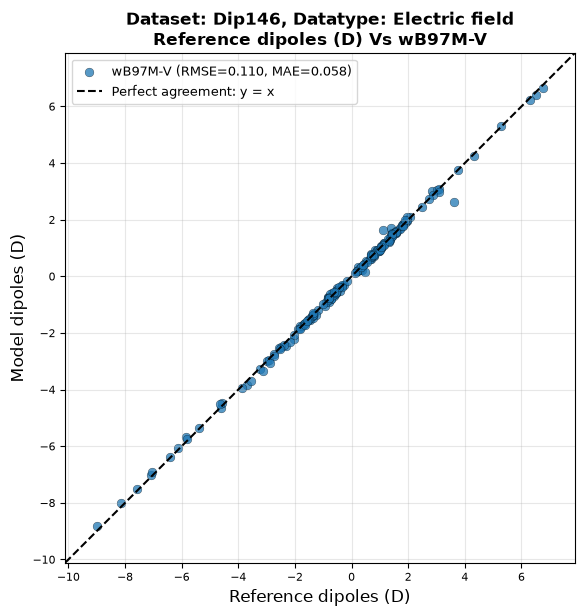

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_wB97M-V_RMSE_MAE.png


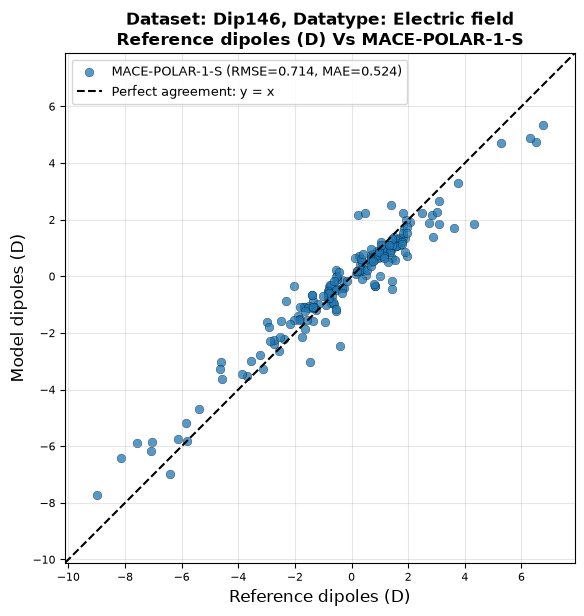

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-s_RMSE_MAE.png


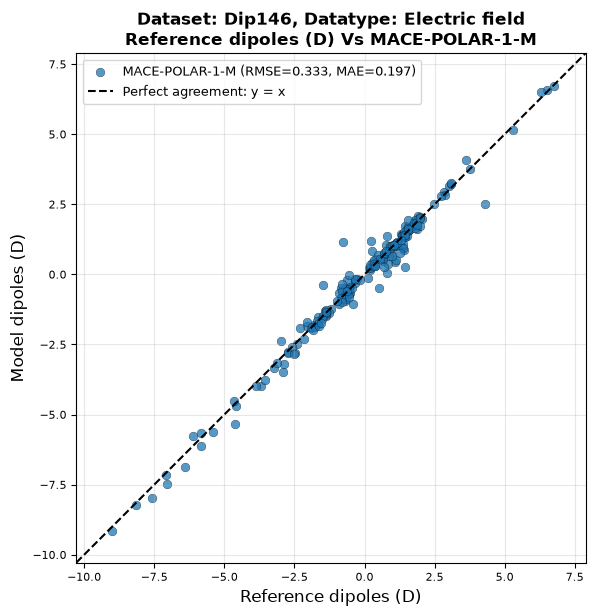

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-m_RMSE_MAE.png


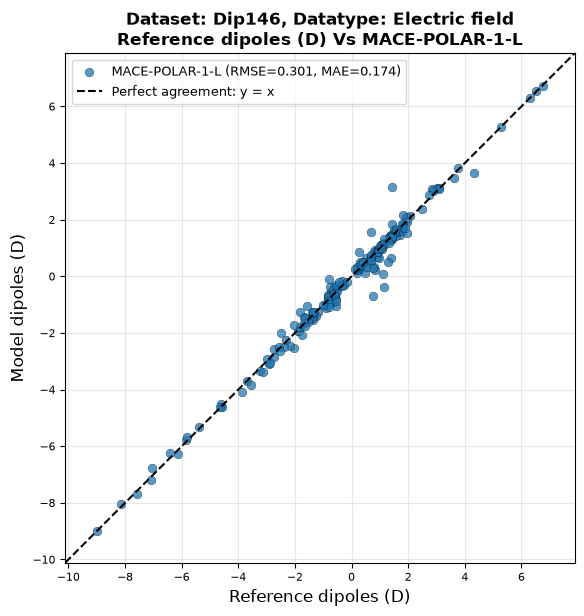

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-l_RMSE_MAE.png


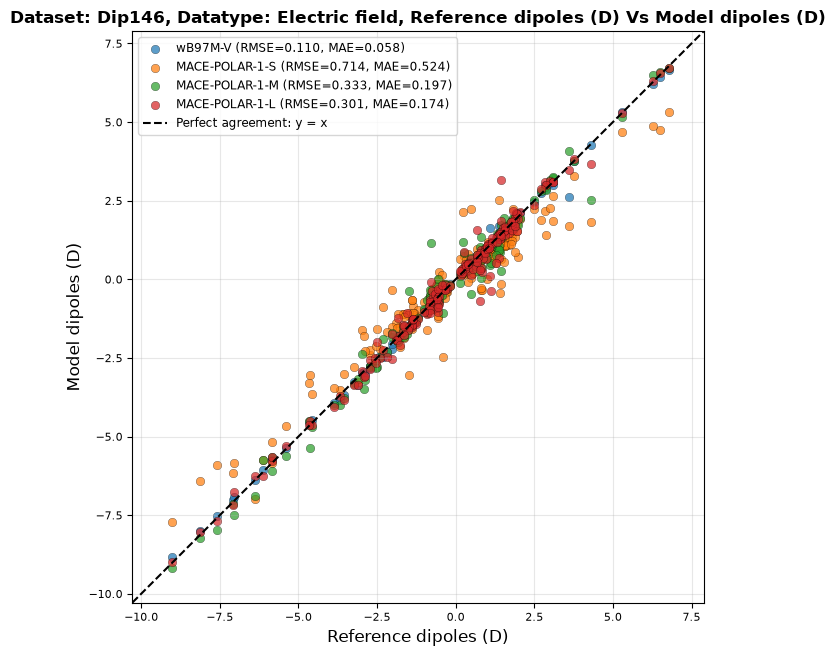

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Figure12_style_all_models_RMSE_MAE.png


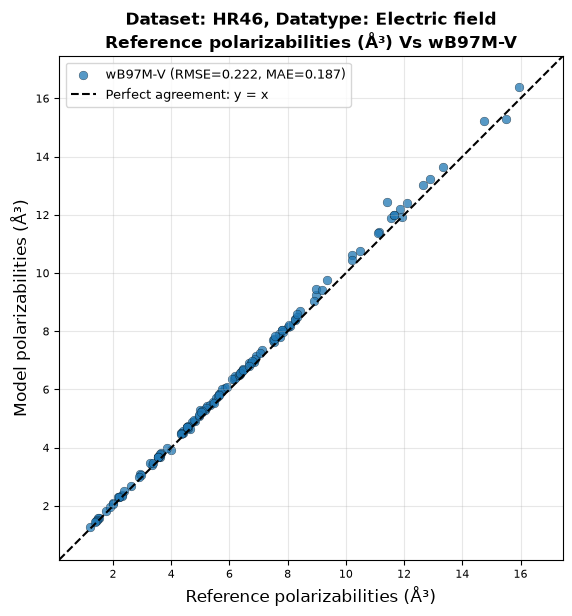

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_wB97M-V_RMSE_MAE.png


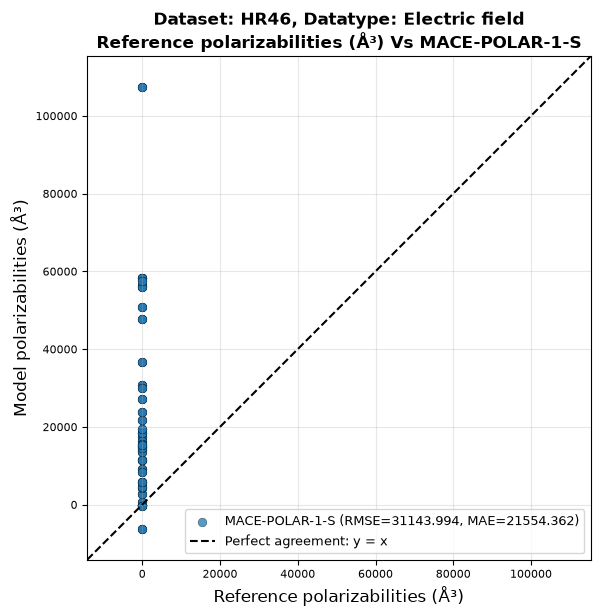

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-s_RMSE_MAE.png


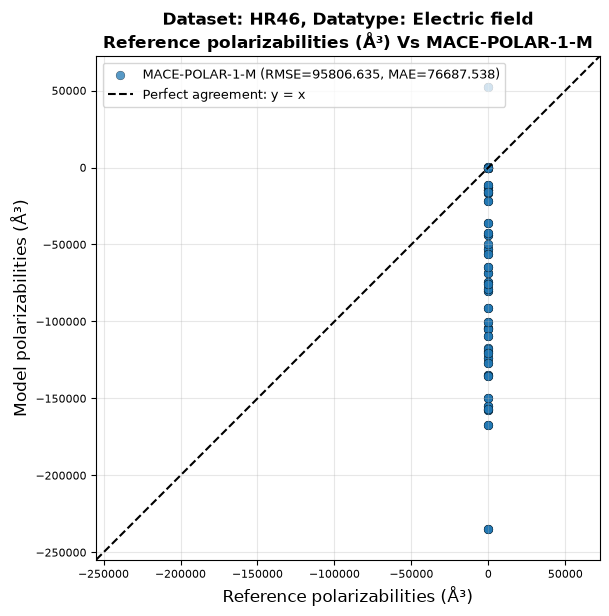

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-m_RMSE_MAE.png


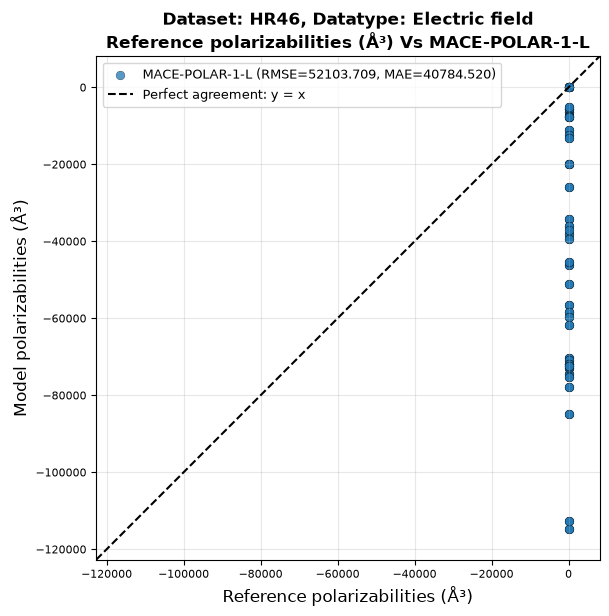

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-l_RMSE_MAE.png


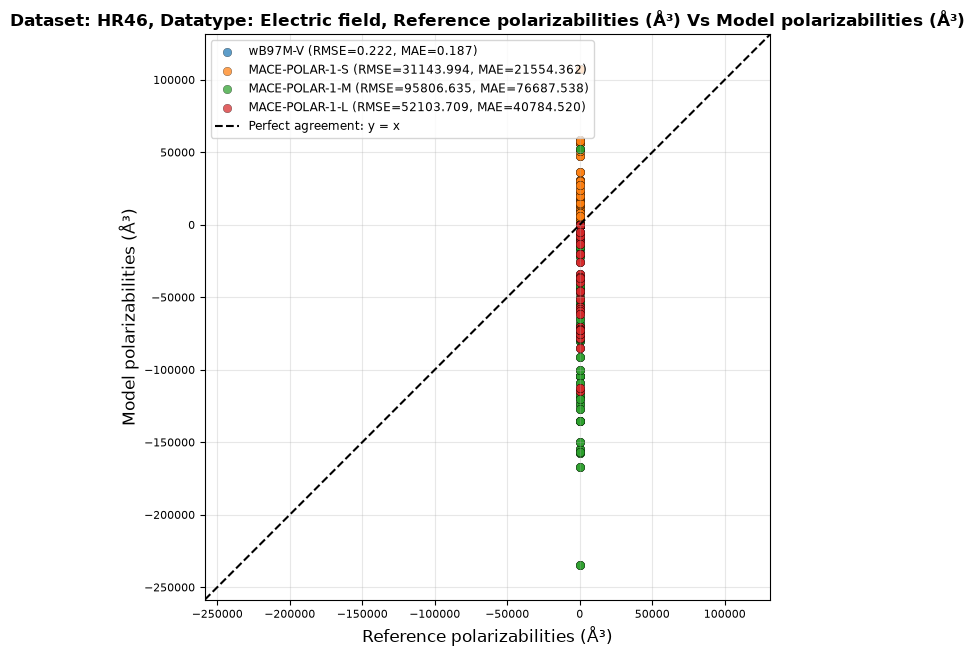

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Figure12_style_all_models_RMSE_MAE.png

Saved combined metrics table:
c:\Users\91988\GSCDB Benchmarking\Analysis\Dip146_HR46_correlation_plot_metrics_RMSE_MAE.csv

Metrics:
  Dataset        Datatype           Model Unit    N          RMSE  \
0  Dip146  Electric field         wB97M-V    D  190      0.109842   
1  Dip146  Electric field  MACE-POLAR-1-S    D  190      0.714442   
2  Dip146  Electric field  MACE-POLAR-1-M    D  190      0.333479   
3  Dip146  Electric field  MACE-POLAR-1-L    D  190      0.300921   
4    HR46  Electric field         wB97M-V   Å³  128      0.222404   
5    HR46  Electric field  MACE-POLAR-1-S   Å³  128  31143.994096   
6    HR46  Electric field  MACE-POLAR-1-M   Å³  128  95806.635008   
7    HR46  Electric field  MACE-POLAR-1-L   Å³  128  52103.708979   

            MAE  Pearson_r  
0      0.057971   0.999008  
1      0.524133   0.965657  
2      0.196818   0.991056  
3      0.173650   0.992516

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Correlation plots for Dip146 and HR46
# Generates:
# 1. Individual Reference vs Model plots
# 2. Extra Figure-12-style all-model plot with RMSE and MAE
# ============================================================

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

MODEL_COLS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

DATASETS = {
    "Dip146": {
        "file": A / "Results_values_with_MACE_POLAR_Dip146_ALL3_CORRECTED.csv",
        "datatype": "Electric field",
        "unit": "D",
        "x_label": "Reference dipoles (D)",
        "y_label": "Model dipoles (D)",
        "title": "Dataset: Dip146, Datatype: Electric field, Reference dipoles (D) Vs Model dipoles (D)",
        "out_prefix": "Dip146",
    },
    "HR46": {
        "file": A / "Results_values_with_MACE_POLAR_HR46_ALL3_CORRECTED.csv",
        "datatype": "Electric field",
        "unit": "Å³",
        "x_label": "Reference polarizabilities (Å³)",
        "y_label": "Model polarizabilities (Å³)",
        "title": "Dataset: HR46, Datatype: Electric field, Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)",
        "out_prefix": "HR46",
    },
}


def calc_metrics(reference, prediction):
    data = pd.DataFrame({"Reference": reference, "Prediction": prediction}).dropna()
    x = data["Reference"].to_numpy(float)
    y = data["Prediction"].to_numpy(float)
    error = y - x

    rmse = np.sqrt(np.mean(error ** 2))
    mae = np.mean(np.abs(error))
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan

    return {
        "N": len(x),
        "RMSE": rmse,
        "MAE": mae,
        "Pearson_r": r,
    }


def get_limits(df, cols):
    values = [pd.to_numeric(df["Reference"], errors="coerce").dropna().to_numpy(float)]

    for col in cols:
        values.append(pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(float))

    values = np.concatenate(values)
    pad = 0.07 * (values.max() - values.min())

    return values.min() - pad, values.max() + pad


all_metric_rows = []

for dataset_name, cfg in DATASETS.items():

    if not cfg["file"].exists():
        raise FileNotFoundError(
            f"File not found for {dataset_name}:\n{cfg['file']}\n\n"
            "Please run the calculation cell first."
        )

    df = pd.read_csv(cfg["file"], index_col=0)

    missing_cols = [col for col in ["Reference"] + MODEL_COLS if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {cfg['file'].name}: {missing_cols}")

    # ========================================================
    # 1. Individual model plots
    # ========================================================

    for model_col in MODEL_COLS:
        metrics = calc_metrics(df["Reference"], df[model_col])
        lo, hi = get_limits(df, [model_col])

        all_metric_rows.append({
            "Dataset": dataset_name,
            "Datatype": cfg["datatype"],
            "Model": LABELS[model_col],
            "Unit": cfg["unit"],
            **metrics,
        })

        plt.figure(figsize=(6.8, 6.2))

        plt.scatter(
            df["Reference"],
            df[model_col],
            s=40,
            alpha=0.75,
            edgecolors="black",
            linewidths=0.25,
            label=f"{LABELS[model_col]} (RMSE={metrics['RMSE']:.3f}, MAE={metrics['MAE']:.3f})",
        )

        plt.plot(
            [lo, hi],
            [lo, hi],
            "--",
            color="black",
            linewidth=1.5,
            label="Perfect agreement: y = x",
        )

        plt.xlim(lo, hi)
        plt.ylim(lo, hi)
        plt.gca().set_aspect("equal", adjustable="box")

        plt.xlabel(cfg["x_label"], fontsize=12)
        plt.ylabel(cfg["y_label"], fontsize=12)
        plt.title(
            f"Dataset: {dataset_name}, Datatype: {cfg['datatype']}\n"
            f"{cfg['x_label']} Vs {LABELS[model_col]}",
            fontsize=12,
            fontweight="bold",
        )

        plt.grid(alpha=0.3)
        plt.legend(fontsize=9)
        plt.tight_layout()

        out = FIG / f"{cfg['out_prefix']}_Reference_vs_{model_col}_RMSE_MAE.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

    # ========================================================
    # 2. Extra Figure-12-style all-model plot
    # ========================================================

    lo, hi = get_limits(df, MODEL_COLS)

    plt.figure(figsize=(7.2, 6.6))

    for model_col in MODEL_COLS:
        metrics = calc_metrics(df["Reference"], df[model_col])

        plt.scatter(
            df["Reference"],
            df[model_col],
            s=38,
            alpha=0.72,
            edgecolors="black",
            linewidths=0.25,
            label=f"{LABELS[model_col]} (RMSE={metrics['RMSE']:.3f}, MAE={metrics['MAE']:.3f})",
        )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(cfg["x_label"], fontsize=12)
    plt.ylabel(cfg["y_label"], fontsize=12)
    plt.title(cfg["title"], fontsize=12, fontweight="bold")

    plt.grid(alpha=0.3)
    plt.legend(fontsize=8.5)
    plt.tight_layout()

    out = FIG / f"{cfg['out_prefix']}_Figure12_style_all_models_RMSE_MAE.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)


metrics_df = pd.DataFrame(all_metric_rows)
metrics_out = A / "Dip146_HR46_correlation_plot_metrics_RMSE_MAE.csv"
metrics_df.to_csv(metrics_out, index=False)

print("\nSaved combined metrics table:")
print(metrics_out)

print("\nMetrics:")
print(metrics_df)

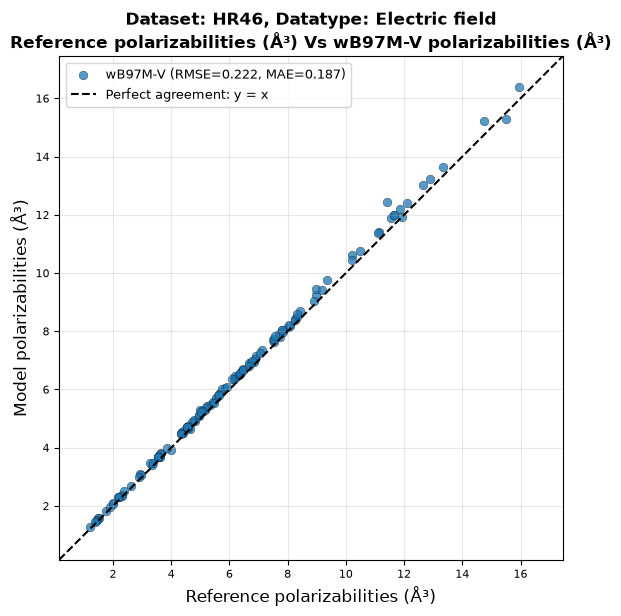

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_wB97M-V_RMSE_MAE_FIXED_V2.png


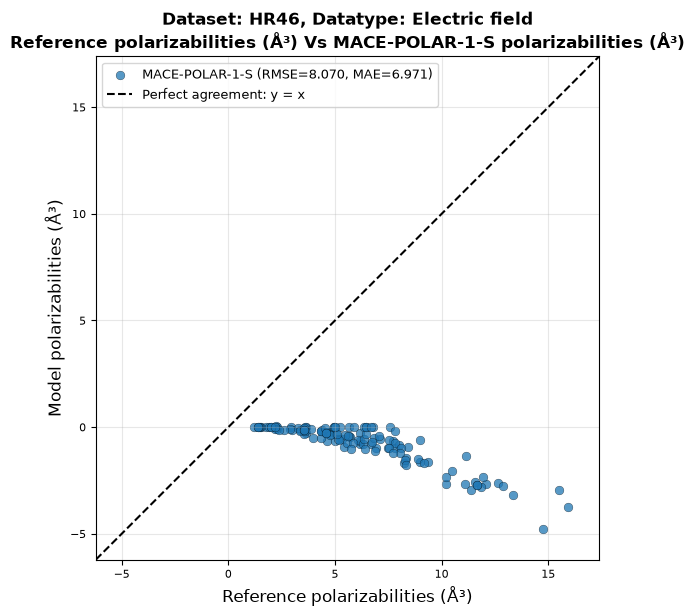

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-s_RMSE_MAE_FIXED_V2.png


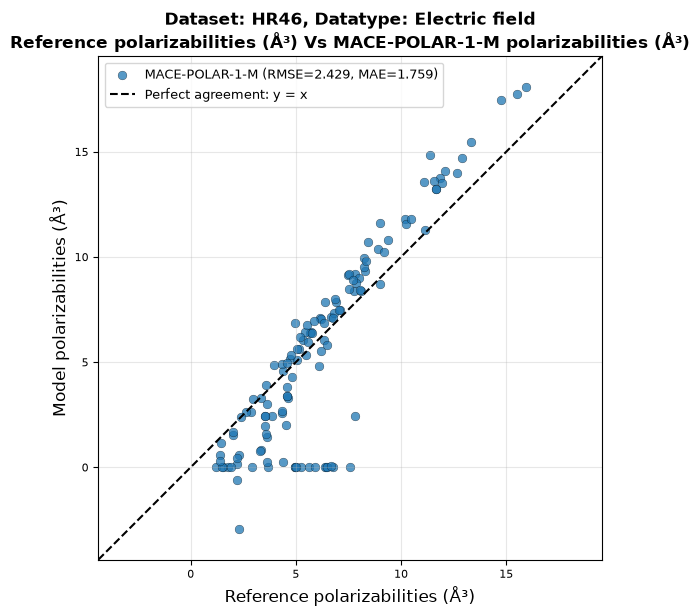

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-m_RMSE_MAE_FIXED_V2.png


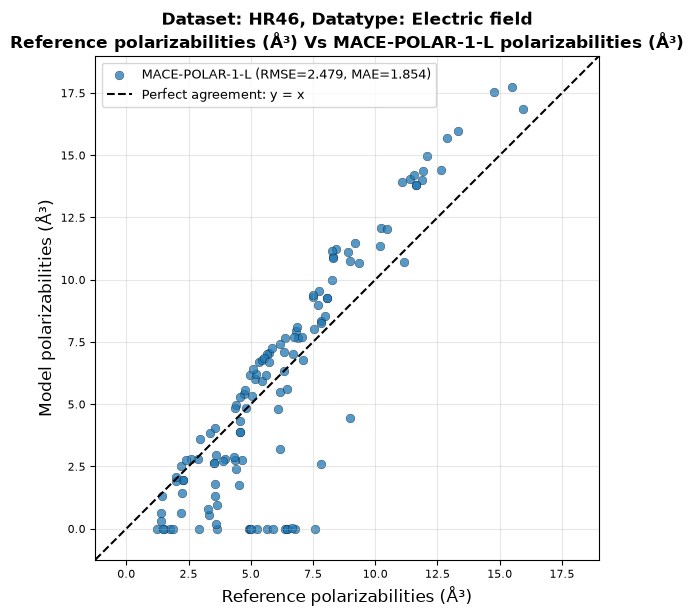

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Reference_vs_mace-polar-1-l_RMSE_MAE_FIXED_V2.png


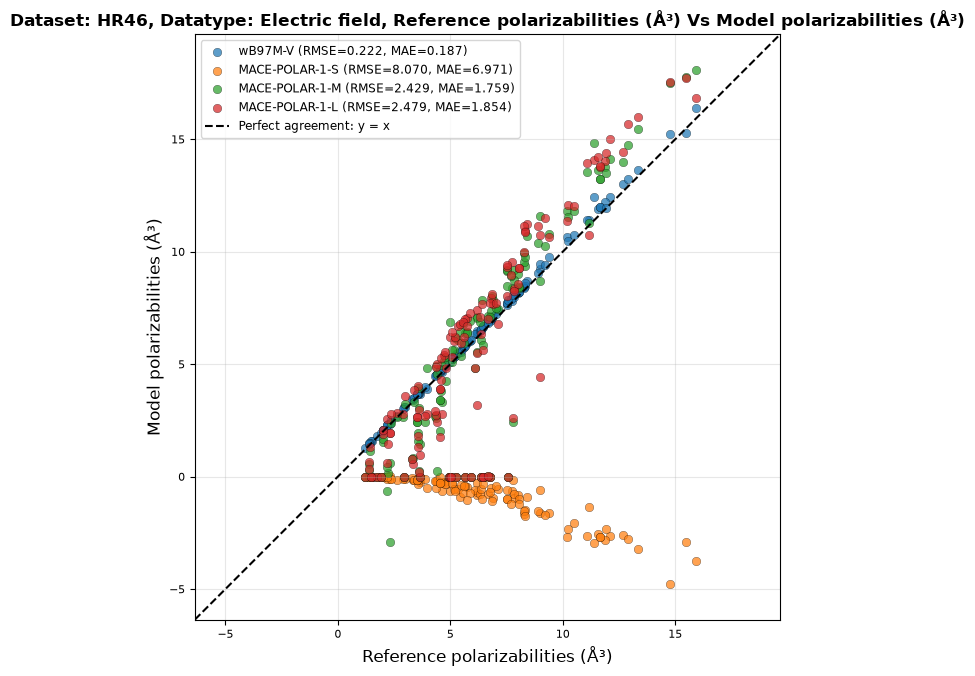

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_Figure12_style_all_models_RMSE_MAE_FIXED_V2.png

Saved metrics:
c:\Users\91988\GSCDB Benchmarking\Analysis\HR46_correlation_plot_metrics_RMSE_MAE_FIXED_V2.csv

Metrics:
  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0    HR46  Electric field         wB97M-V   Å³  128  0.222404  0.187419   
1    HR46  Electric field  MACE-POLAR-1-S   Å³  128  8.070475  6.971126   
2    HR46  Electric field  MACE-POLAR-1-M   Å³  128  2.428878  1.759354   
3    HR46  Electric field  MACE-POLAR-1-L   Å³  128  2.478802  1.854411   

   Pearson_r  
0   0.999472  
1  -0.896211  
2   0.896550  
3   0.881166  


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

DATASET = "HR46"
DATATYPE = "Electric field"
UNIT = "Å³"

df = pd.read_csv(A / "Results_values_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv", index_col=0)

models = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

labels = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

def metric(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAE": np.mean(np.abs(e)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def get_limits(*series):
    values = np.concatenate([
        pd.to_numeric(s, errors="coerce").dropna().to_numpy(float)
        for s in series
    ])

    pad = 0.07 * (values.max() - values.min())

    return values.min() - pad, values.max() + pad

metric_rows = []

for model in models:
    m = metric(df["Reference"], df[model])
    metric_rows.append({
        "Dataset": DATASET,
        "Datatype": DATATYPE,
        "Model": labels[model],
        "Unit": UNIT,
        **m,
    })

    lo, hi = get_limits(df["Reference"], df[model])

    plt.figure(figsize=(6.8, 6.2))

    plt.scatter(
        df["Reference"],
        df[model],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{labels[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f})",
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
    plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

    plt.title(
        f"Dataset: {DATASET}, Datatype: {DATATYPE}\n"
        f"Reference polarizabilities (Å³) Vs {labels[model]} polarizabilities (Å³)",
        fontsize=12,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()

    out = FIG / f"HR46_Reference_vs_{model}_RMSE_MAE_FIXED_V2.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

lo, hi = get_limits(df["Reference"], *[df[m] for m in models])

plt.figure(figsize=(7.4, 6.8))

for model in models:
    m = metric(df["Reference"], df[model])

    plt.scatter(
        df["Reference"],
        df[model],
        s=38,
        alpha=0.72,
        edgecolors="black",
        linewidths=0.25,
        label=f"{labels[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

plt.title(
    "Dataset: HR46, Datatype: Electric field, "
    "Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8.5)
plt.tight_layout()

out = FIG / "HR46_Figure12_style_all_models_RMSE_MAE_FIXED_V2.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

metric_df = pd.DataFrame(metric_rows)
metric_out = A / "HR46_correlation_plot_metrics_RMSE_MAE_FIXED_V2.csv"
metric_df.to_csv(metric_out, index=False)

print("\nSaved metrics:")
print(metric_out)

print("\nMetrics:")
print(metric_df)

  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0    HR46  Electric field         wB97M-V   Å³  128  0.222404  0.187419   
1    HR46  Electric field  MACE-POLAR-1-S   Å³  128  8.070475  6.971126   
2    HR46  Electric field  MACE-POLAR-1-M   Å³  128  2.428878  1.759354   
3    HR46  Electric field  MACE-POLAR-1-L   Å³  128  2.478802  1.854411   

   Pearson_r  
0   0.999472  
1  -0.896211  
2   0.896550  
3   0.881166  

Saved metric check:
c:\Users\91988\GSCDB Benchmarking\Analysis\HR46_FIXED_V2_plot_metrics_check.csv


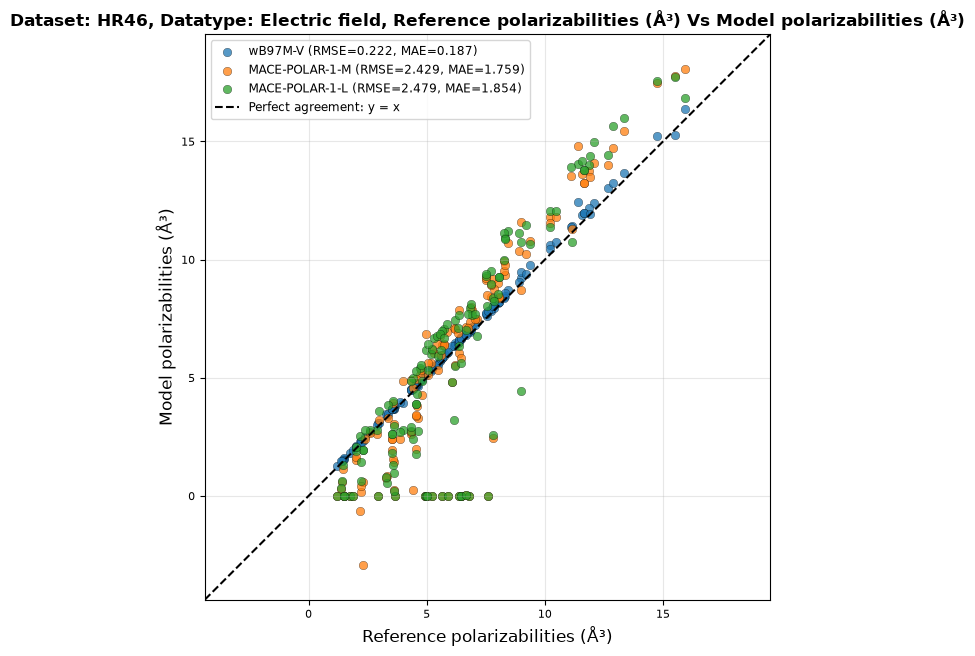

Saved paper-style plot:
c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_PAGE23_STYLE_wB97MV_MACE_M_L_RMSE_MAE.png


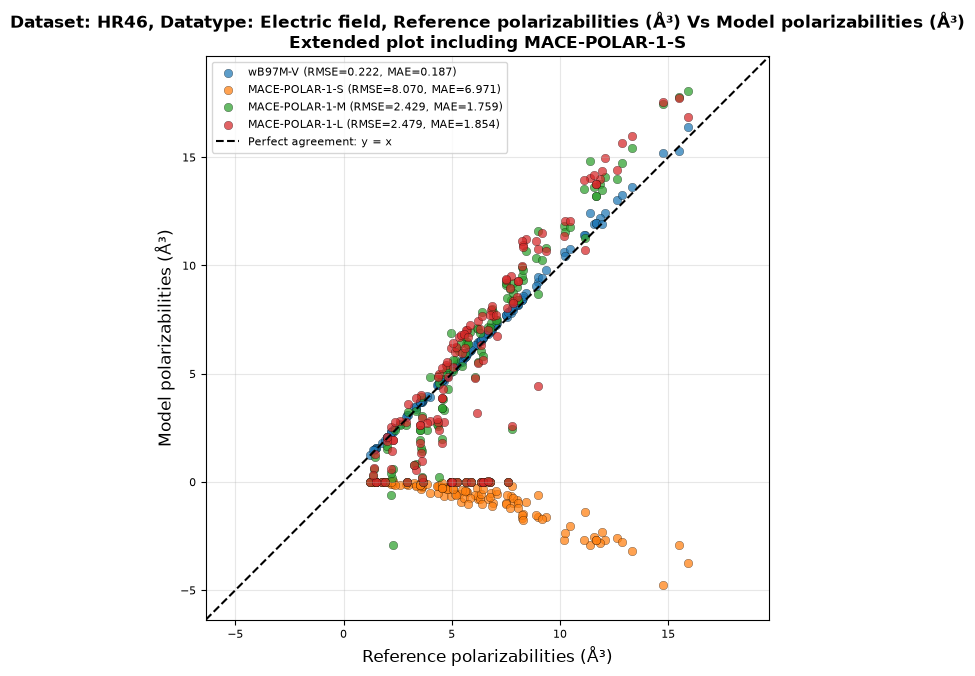

Saved extended all-model plot:
c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\HR46_EXTENDED_ALL4_MODELS_RMSE_MAE.png


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Correct HR46 plotting script
# Uses your FIXED_V2 Results_values file
# ============================================================

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

DATASET = "HR46"
DATATYPE = "Electric field"
UNIT = "Å³"

file = A / "Results_values_with_MACE_POLAR_HR46_ALL3_FIXED_V2.csv"
df = pd.read_csv(file, index_col=0)

labels = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

def metric(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x
    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAE": np.mean(np.abs(e)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def get_limits(df, cols, include_reference=True):
    vals = []
    if include_reference:
        vals.append(pd.to_numeric(df["Reference"], errors="coerce").dropna().to_numpy(float))
    for col in cols:
        vals.append(pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(float))
    vals = np.concatenate(vals)
    pad = 0.07 * (vals.max() - vals.min())
    return vals.min() - pad, vals.max() + pad

# ============================================================
# 1. Print metric table
# ============================================================

all_models = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

rows = []
for model in all_models:
    m = metric(df["Reference"], df[model])
    rows.append({
        "Dataset": DATASET,
        "Datatype": DATATYPE,
        "Model": labels[model],
        "Unit": UNIT,
        **m,
    })

metric_df = pd.DataFrame(rows)
print(metric_df)

metric_out = A / "HR46_FIXED_V2_plot_metrics_check.csv"
metric_df.to_csv(metric_out, index=False)
print("\nSaved metric check:")
print(metric_out)

# ============================================================
# 2. Paper-style plot: only models shown on page 23
# ============================================================

paper_models = ["wB97M-V", "mace-polar-1-m", "mace-polar-1-l"]

lo, hi = get_limits(df, paper_models)

plt.figure(figsize=(7.2, 6.6))

for model in paper_models:
    m = metric(df["Reference"], df[model])
    plt.scatter(
        df["Reference"],
        df[model],
        s=38,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{labels[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

plt.title(
    "Dataset: HR46, Datatype: Electric field, "
    "Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8.5)
plt.tight_layout()

out = FIG / "HR46_PAGE23_STYLE_wB97MV_MACE_M_L_RMSE_MAE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved paper-style plot:")
print(out)

# ============================================================
# 3. Extended plot: includes MACE-POLAR-1-S also
# ============================================================

extended_models = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

lo, hi = get_limits(df, extended_models)

plt.figure(figsize=(7.4, 6.8))

for model in extended_models:
    m = metric(df["Reference"], df[model])
    plt.scatter(
        df["Reference"],
        df[model],
        s=38,
        alpha=0.72,
        edgecolors="black",
        linewidths=0.25,
        label=f"{labels[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

plt.title(
    "Dataset: HR46, Datatype: Electric field, "
    "Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)\n"
    "Extended plot including MACE-POLAR-1-S",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8.2)
plt.tight_layout()

out = FIG / "HR46_EXTENDED_ALL4_MODELS_RMSE_MAE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved extended all-model plot:")
print(out)

In [1]:
from pathlib import Path
import re, gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar
try:
    import torch
except Exception:
    torch = None

DATASET, UNIT = "T144", "Å³"
MODELS = {"mace-polar-1-s":"polar-1-s", "mace-polar-1-m":"polar-1-m", "mace-polar-1-l":"polar-1-l"}
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"

EV_TO_KCAL = 23.06054783
HARTREE_TO_KCAL = 627.50947406
BOHR_TO_ANG = 0.529177
FIELD_AU_TO_VA = 51.4220674763

# T144 uses the same polarizability conversion as HR46 in analyze.ipynb
T144_STEP_AU = 0.004
KCAL_TO_A3 = (BOHR_TO_ANG ** 3) / (HARTREE_TO_KCAL * T144_STEP_AU ** 2)

def root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q/x).exists() for x in ["Analysis","Info","xyz_files","qchem_inputs"]): return q
    raise FileNotFoundError("Run from GSCDB root or GSCDB/Analysis.")

ROOT = root()
A, I, X, Q = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files", ROOT/"qchem_inputs"
FIG = A/"Figures"; FIG.mkdir(exist_ok=True)

mol_out = A/"Molecule_Energies_MACE_POLAR_T144_ALL3.csv"
rxn_out = A/"Reaction_Energies_with_MACE_POLAR_T144_ALL3.csv"
val_out = A/"Results_values_with_MACE_POLAR_T144_ALL3.csv"
err_out = A/"Results_errors_with_MACE_POLAR_T144_ALL3.csv"
met_out = A/"T144_ALL3_metrics.csv"
log_out = A/"Molecule_Energies_MACE_POLAR_T144_ALL3_error_log.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("T144_STEP_AU:", T144_STEP_AU)
print("KCAL_TO_A3:", KCAL_TO_A3)

def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem(qf):
    charge, mult, field = 0, 1, np.zeros(3)
    if not qf.exists(): return charge, mult, field
    lines = qf.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        s = line.strip().lower()
        if s == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip(): j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2: charge, mult = int(float(p[0])), int(float(p[1]))
        if s == "$multipole_field":
            d, j = {"X":0.0,"Y":0.0,"Z":0.0}, i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                p = lines[j].split()
                if len(p) == 2 and p[0].upper() in d: d[p[0].upper()] = float(p[1])
                j += 1
            field = np.array([d["X"], d["Y"], d["Z"]], float)
    return charge, mult, field

def field_from_t144_name(mol):
    m = re.search(r"([012])([+-])$", mol)
    if not m: return np.zeros(3)
    f = np.zeros(3)
    f[int(m.group(1))] = T144_STEP_AU if m.group(2) == "+" else -T144_STEP_AU
    return f

def prepare_atoms(mol):
    xf, qf = X/f"{mol}.xyz", Q/f"{mol}.in"
    charge, mult, field = read_qchem(qf)
    atoms = read(xf)
    charge = int(float(atoms.info.get("charge", charge)))
    mult = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", mult))))
    if np.allclose(field, 0): field = field_from_t144_name(mol)
    atoms.positions -= atoms.positions.mean(axis=0)
    atoms.info["charge"], atoms.info["spin"] = charge, mult
    atoms.info["external_field"] = field * FIELD_AU_TO_VA
    return atoms, charge, mult, field

def mols(st): return [p.strip() for p in str(st).split(",")][1::2]

def rxn_energy(st, dfm, col):
    p, e = [x.strip() for x in str(st).split(",")], 0.0
    for i in range(0, len(p), 2):
        c, m = float(p[i]), p[i+1]
        if m not in dfm.index or pd.isna(dfm.loc[m, col]): return np.nan
        e += c * float(dfm.loc[m, col])
    return e * EV_TO_KCAL

def metrics(ref, pred):
    d = pd.DataFrame({"x":ref, "y":pred}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    er = y - x
    return len(x), np.sqrt(np.mean(er**2)), np.mean(np.abs(er)), np.corrcoef(x, y)[0,1]

df_eval = pd.read_csv(I/"DatasetEval.csv", index_col=0)
df_rxn_all = pd.read_csv(A/"Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A/"Results_values.csv", index_col=0)
df_info = pd.read_csv(I/"Datasets.csv", index_col=0)

ev = df_eval[df_eval["Dataset"] == DATASET].copy()
rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()
datatype = df_info.loc[DATASET, "Datatype"]

print("\nDataset:", DATASET)
print("Datatype:", datatype)
print("Rows:", len(ev))
print("Existing wB97M-V MAE:", np.mean(np.abs(val_base["wB97M-V"] - val_base["Reference"])))
print("Max conversion mismatch wB97M-V:", np.nanmax(np.abs(rxn_base["wB97M-V"] * KCAL_TO_A3 - val_base["wB97M-V"])))

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols(st)})
print("Unique molecules:", len(all_mols))

meta = []
for m in all_mols:
    at, ch, sp, f = prepare_atoms(m)
    meta.append({"Molecule":m, "charge":ch, "multiplicity":sp, "num_atoms":len(at),
                 "field_au_x":f[0], "field_au_y":f[1], "field_au_z":f[2],
                 "field_VA_x":f[0]*FIELD_AU_TO_VA, "field_VA_y":f[1]*FIELD_AU_TO_VA, "field_VA_z":f[2]*FIELD_AU_TO_VA})
df_mol = pd.DataFrame(meta).set_index("Molecule")

print("\nField counts:")
print(df_mol[["field_au_x","field_au_y","field_au_z"]].value_counts().head(20))

base_mask = ~df_mol.index.to_series().str.contains(r"[012][+-]$", regex=True)
if (df_mol.loc[base_mask, ["field_au_x","field_au_y","field_au_z"]].abs().sum(axis=1) > 1e-15).any():
    raise ValueError("Some zero-field T144 base molecules have non-zero field.")

errs = []
for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)
    df_mol[col] = np.nan
    for n, m in enumerate(tqdm(all_mols, desc=col), 1):
        try:
            at, ch, sp, f = prepare_atoms(m)
            reset_calc(calc); at.calc = calc
            df_mol.loc[m, col] = float(at.get_potential_energy())
        except Exception as exc:
            errs.append({"Molecule":m, "Model":col, "Error":repr(exc)})
        if n % 10 == 0: df_mol.to_csv(mol_out)
    df_mol.to_csv(mol_out)
    del calc; gc.collect()
    if torch is not None and torch.cuda.is_available(): torch.cuda.empty_cache()

pd.DataFrame(errs).to_csv(log_out, index=False)
df_mol.to_csv(mol_out)

df_rxn = rxn_base.copy()
for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="T144 reaction energies"):
    for col in MODELS: df_rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], df_mol, col)
df_rxn.to_csv(rxn_out)

df_val = val_base.copy()
for col in MODELS: df_val[col] = df_rxn[col] * KCAL_TO_A3
df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset","Reaction","Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")
df_err.to_csv(err_out)

rows = []
for col in ["wB97M-V", *MODELS]:
    n, rmse, mae, r = metrics(df_val["Reference"], df_val[col])
    rows.append({"Dataset":DATASET, "Datatype":datatype, "Model":col, "Unit":UNIT, "N":n, "RMSE":rmse, "MAE":mae, "Pearson_r":r})
df_met = pd.DataFrame(rows)
df_met.to_csv(met_out, index=False)

print("\nReaction-energy check:")
for col in MODELS:
    print(col, "| zeros:", np.isclose(df_rxn[col], 0).sum(), "| unique:", df_rxn[col].nunique(), "| min/max:", df_rxn[col].min(), df_rxn[col].max())

print("\nMetric table:")
print(df_met)

print("\nSaved files:")
for f in [mol_out, rxn_out, val_out, err_out, met_out, log_out]: print(f)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: c:\Users\91988\GSCDB Benchmarking
DEVICE: cpu
T144_STEP_AU: 0.004
KCAL_TO_A3: 14.759192930677115

Dataset: T144
Datatype: Electric field
Rows: 421
Existing wB97M-V MAE: 0.28393392000243123
Max conversion mismatch wB97M-V: 7.105427357601002e-15
Unique molecules: 986

Field counts:
field_au_x  field_au_y  field_au_z
 0.000       0.000       0.000        144
 0.004       0.000       0.000        144
-0.004       0.000       0.000        144
 0.000       0.000       0.004        142
                        -0.004        142
             0.004       0.000        135
            -0.004       0.000        135
Name: count, dtype: int64

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 986/986 [06:32<00:00,  2.51it/s]



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-m: 100%|██████████| 986/986 [12:21<00:00,  1.33it/s]



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
T144 reaction energies: 100%|██████████| 421/421 [00:00<00:00, 555.35it/s]



Reaction-energy check:
mace-polar-1-s | zeros: 24 | unique: 399 | min/max: -1.0784700956112525 4.068009600002188e-07
mace-polar-1-m | zeros: 26 | unique: 398 | min/max: -1.0939749470824608e-07 1.930897701591482
mace-polar-1-l | zeros: 29 | unique: 398 | min/max: -1.8456632542802254e-08 1.6784518443939338

Metric table:
  Dataset        Datatype           Model Unit    N       RMSE        MAE  \
0    T144  Electric field         wB97M-V   Å³  421   0.365754   0.283934   
1    T144  Electric field  mace-polar-1-s   Å³  421  12.541303  10.905159   
2    T144  Electric field  mace-polar-1-m   Å³  421   2.902776   2.196059   
3    T144  Electric field  mace-polar-1-l   Å³  421   2.999524   2.312143   

   Pearson_r  
0   0.998419  
1  -0.814120  
2   0.881362  
3   0.857763  

Saved files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_T144_ALL3.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_T144_ALL3.csv
c:\Users\91988\GSCDB Bench

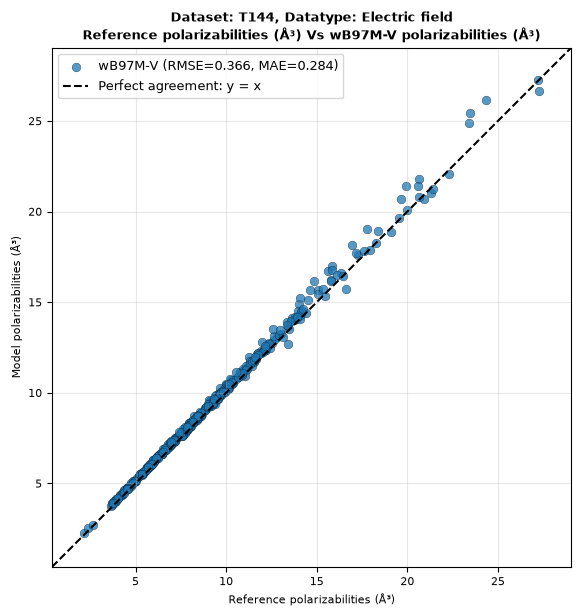

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\T144_Reference_vs_wB97M-V_RMSE_MAE.png


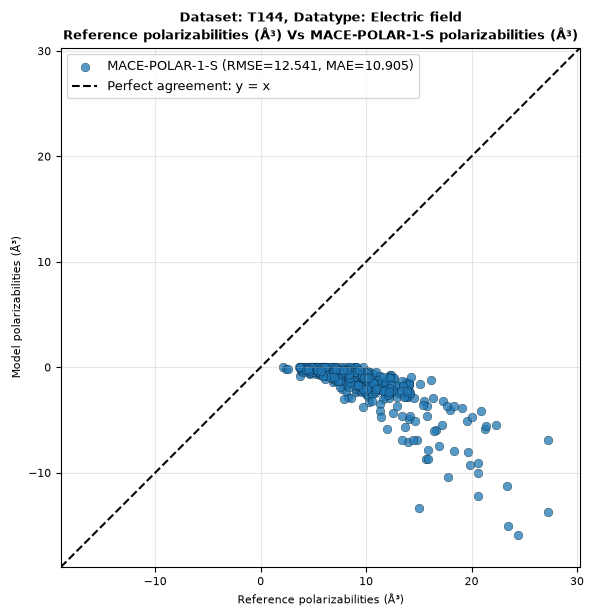

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\T144_Reference_vs_mace-polar-1-s_RMSE_MAE.png


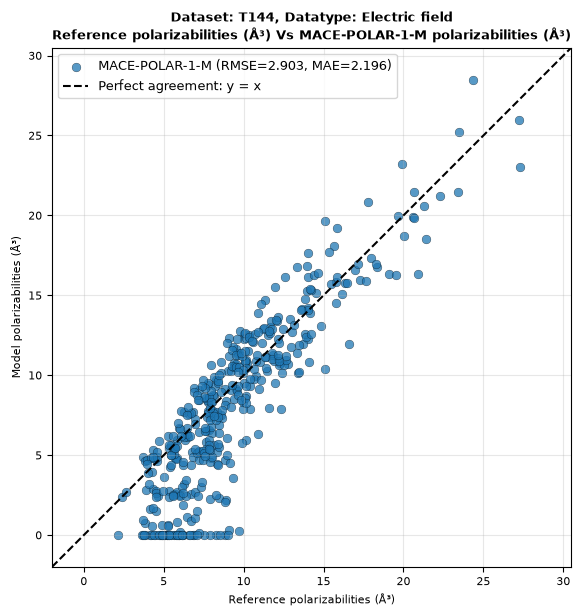

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\T144_Reference_vs_mace-polar-1-m_RMSE_MAE.png


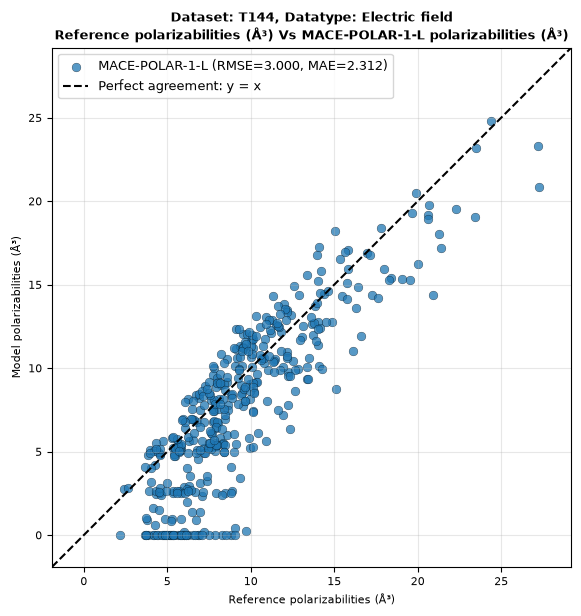

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\T144_Reference_vs_mace-polar-1-l_RMSE_MAE.png


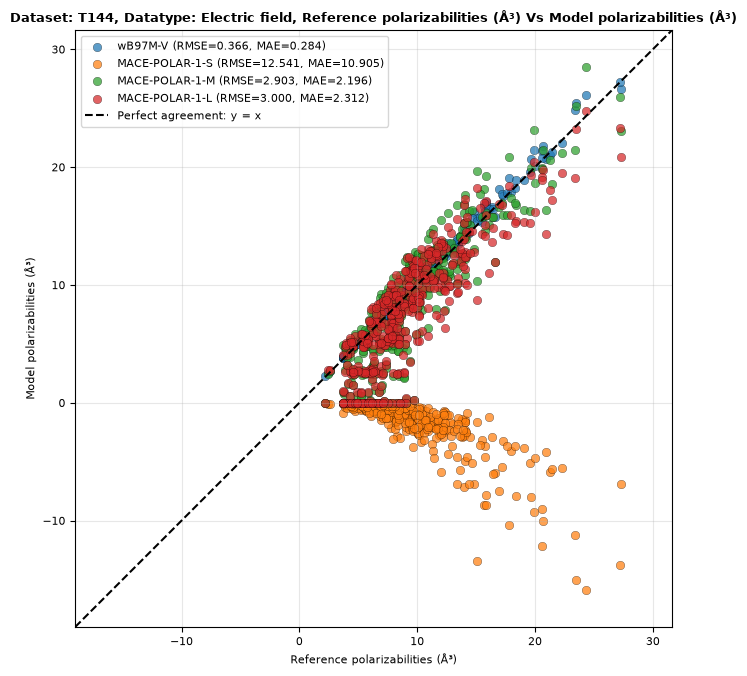

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\T144_Figure12_style_all_models_RMSE_MAE.png
  Dataset        Datatype           Model Unit    N       RMSE        MAE  \
0    T144  Electric field         wB97M-V   Å³  421   0.365754   0.283934   
1    T144  Electric field  MACE-POLAR-1-S   Å³  421  12.541303  10.905159   
2    T144  Electric field  MACE-POLAR-1-M   Å³  421   2.902776   2.196059   
3    T144  Electric field  MACE-POLAR-1-L   Å³  421   2.999524   2.312143   

   Pearson_r  
0   0.998419  
1  -0.814120  
2   0.881362  
3   0.857763  


In [2]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT/"Analysis").exists(): ROOT = ROOT.parent
A, FIG = ROOT/"Analysis", ROOT/"Analysis"/"Figures"
FIG.mkdir(exist_ok=True)

DATASET, DATATYPE, UNIT = "T144", "Electric field", "Å³"
df = pd.read_csv(A/"Results_values_with_MACE_POLAR_T144_ALL3.csv", index_col=0)

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
LABELS = {"wB97M-V":"wB97M-V", "mace-polar-1-s":"MACE-POLAR-1-S",
          "mace-polar-1-m":"MACE-POLAR-1-M", "mace-polar-1-l":"MACE-POLAR-1-L"}

def met(x, y):
    d = pd.DataFrame({"x":x, "y":y}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    return len(x), np.sqrt(np.mean(e**2)), np.mean(np.abs(e)), np.corrcoef(x,y)[0,1]

def lim(*s):
    v = np.concatenate([pd.to_numeric(x, errors="coerce").dropna().to_numpy(float) for x in s])
    p = 0.07 * (v.max() - v.min())
    return v.min()-p, v.max()+p

rows = []
for m in MODELS:
    n, rmse, mae, r = met(df["Reference"], df[m])
    rows.append({"Dataset":DATASET,"Datatype":DATATYPE,"Model":LABELS[m],"Unit":UNIT,"N":n,"RMSE":rmse,"MAE":mae,"Pearson_r":r})
    lo, hi = lim(df["Reference"], df[m])
    plt.figure(figsize=(6.8,6.2))
    plt.scatter(df["Reference"], df[m], s=40, alpha=0.75, edgecolors="black", linewidths=0.25,
                label=f"{LABELS[m]} (RMSE={rmse:.3f}, MAE={mae:.3f})")
    plt.plot([lo,hi],[lo,hi],"--",color="black",linewidth=1.5,label="Perfect agreement: y = x")
    plt.xlim(lo,hi); plt.ylim(lo,hi); plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Reference polarizabilities (Å³)")
    plt.ylabel("Model polarizabilities (Å³)")
    plt.title(f"Dataset: T144, Datatype: Electric field\nReference polarizabilities (Å³) Vs {LABELS[m]} polarizabilities (Å³)", fontweight="bold")
    plt.grid(alpha=0.3); plt.legend(fontsize=9); plt.tight_layout()
    out = FIG/f"T144_Reference_vs_{m}_RMSE_MAE.png"
    plt.savefig(out, dpi=300); plt.show()
    print("Saved:", out)

lo, hi = lim(df["Reference"], *[df[m] for m in MODELS])
plt.figure(figsize=(7.4,6.8))
for m in MODELS:
    n, rmse, mae, r = met(df["Reference"], df[m])
    plt.scatter(df["Reference"], df[m], s=38, alpha=0.72, edgecolors="black", linewidths=0.25,
                label=f"{LABELS[m]} (RMSE={rmse:.3f}, MAE={mae:.3f})")
plt.plot([lo,hi],[lo,hi],"--",color="black",linewidth=1.5,label="Perfect agreement: y = x")
plt.xlim(lo,hi); plt.ylim(lo,hi); plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Reference polarizabilities (Å³)")
plt.ylabel("Model polarizabilities (Å³)")
plt.title("Dataset: T144, Datatype: Electric field, Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)", fontweight="bold")
plt.grid(alpha=0.3); plt.legend(fontsize=8.2); plt.tight_layout()
out = FIG/"T144_Figure12_style_all_models_RMSE_MAE.png"
plt.savefig(out, dpi=300); plt.show()
print("Saved:", out)

metrics = pd.DataFrame(rows)
metrics.to_csv(A/"T144_correlation_plot_metrics_RMSE_MAE.csv", index=False)
print(metrics)

In [3]:
from pathlib import Path
import re, gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar
try:
    import torch
except Exception:
    torch = None

DATASET, UNIT = "OEEF", "kcal/mol"
MODELS = {"mace-polar-1-s":"polar-1-s", "mace-polar-1-m":"polar-1-m", "mace-polar-1-l":"polar-1-l"}
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"

EV_TO_KCAL = 23.06054783
FIELD_AU_TO_VA = 51.4220674763

def root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q/x).exists() for x in ["Analysis","Info","xyz_files","qchem_inputs"]): return q
    raise FileNotFoundError("Run from GSCDB root or GSCDB/Analysis.")

ROOT = root()
A, I, X, Q = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files", ROOT/"qchem_inputs"
FIG = A/"Figures"; FIG.mkdir(exist_ok=True)

mol_out = A/"Molecule_Energies_MACE_POLAR_OEEF_ALL3.csv"
rxn_out = A/"Reaction_Energies_with_MACE_POLAR_OEEF_ALL3.csv"
val_out = A/"Results_values_with_MACE_POLAR_OEEF_ALL3.csv"
err_out = A/"Results_errors_with_MACE_POLAR_OEEF_ALL3.csv"
met_out = A/"OEEF_ALL3_metrics.csv"
log_out = A/"Molecule_Energies_MACE_POLAR_OEEF_ALL3_error_log.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("OEEF final unit:", UNIT)

def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem(qf):
    charge, mult, field = 0, 1, np.zeros(3)
    if not qf.exists(): return charge, mult, field
    lines = qf.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        s = line.strip().lower()
        if s == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip(): j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2: charge, mult = int(float(p[0])), int(float(p[1]))
        if s == "$multipole_field":
            d, j = {"X":0.0,"Y":0.0,"Z":0.0}, i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                p = lines[j].split()
                if len(p) == 2 and p[0].upper() in d: d[p[0].upper()] = float(p[1])
                j += 1
            field = np.array([d["X"], d["Y"], d["Z"]], float)
    return charge, mult, field

def field_from_oeef_name(mol):
    m = re.search(r"_([-+]?\d*\.?\d+)$", mol)
    if not m: return np.zeros(3)
    return np.array([0.0, 0.0, -float(m.group(1))], float)

def prepare_atoms(mol):
    xf, qf = X/f"{mol}.xyz", Q/f"{mol}.in"
    charge, mult, field = read_qchem(qf)
    atoms = read(xf)
    charge = int(float(atoms.info.get("charge", charge)))
    mult = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", mult))))
    if np.allclose(field, 0): field = field_from_oeef_name(mol)
    atoms.positions -= atoms.positions.mean(axis=0)
    atoms.info["charge"], atoms.info["spin"] = charge, mult
    atoms.info["external_field"] = field * FIELD_AU_TO_VA
    return atoms, charge, mult, field

def mols(st): return [p.strip() for p in str(st).split(",")][1::2]

def rxn_energy(st, dfm, col):
    p, e = [x.strip() for x in str(st).split(",")], 0.0
    for i in range(0, len(p), 2):
        c, m = float(p[i]), p[i+1]
        if m not in dfm.index or pd.isna(dfm.loc[m, col]): return np.nan
        e += c * float(dfm.loc[m, col])
    return e * EV_TO_KCAL

def metrics(ref, pred):
    d = pd.DataFrame({"x":ref, "y":pred}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    er = y - x
    return len(x), np.sqrt(np.mean(er**2)), np.mean(np.abs(er)), np.corrcoef(x, y)[0,1]

df_eval = pd.read_csv(I/"DatasetEval.csv", index_col=0)
df_rxn_all = pd.read_csv(A/"Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A/"Results_values.csv", index_col=0)
df_info = pd.read_csv(I/"Datasets.csv", index_col=0)

ev = df_eval[df_eval["Dataset"] == DATASET].copy()
rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()
datatype = df_info.loc[DATASET, "Datatype"]

print("\nDataset:", DATASET)
print("Datatype:", datatype)
print("Rows:", len(ev))
print("Existing wB97M-V MAE:", np.mean(np.abs(val_base["wB97M-V"] - val_base["Reference"])))
print("Max Reaction_Energies vs Results_values mismatch wB97M-V:",
      np.nanmax(np.abs(rxn_base["wB97M-V"] - val_base["wB97M-V"])))

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols(st)})
print("Unique molecules:", len(all_mols))

meta = []
for m in all_mols:
    at, ch, sp, f = prepare_atoms(m)
    meta.append({"Molecule":m, "charge":ch, "multiplicity":sp, "num_atoms":len(at),
                 "field_au_x":f[0], "field_au_y":f[1], "field_au_z":f[2],
                 "field_VA_x":f[0]*FIELD_AU_TO_VA, "field_VA_y":f[1]*FIELD_AU_TO_VA, "field_VA_z":f[2]*FIELD_AU_TO_VA})
df_mol = pd.DataFrame(meta).set_index("Molecule")

print("\nField counts:")
print(df_mol[["field_au_x","field_au_y","field_au_z"]].value_counts().head(20))

errs = []
for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)
    df_mol[col] = np.nan
    for n, m in enumerate(tqdm(all_mols, desc=col), 1):
        try:
            at, ch, sp, f = prepare_atoms(m)
            reset_calc(calc); at.calc = calc
            df_mol.loc[m, col] = float(at.get_potential_energy())
        except Exception as exc:
            errs.append({"Molecule":m, "Model":col, "Error":repr(exc)})
        if n % 10 == 0: df_mol.to_csv(mol_out)
    df_mol.to_csv(mol_out)
    del calc; gc.collect()
    if torch is not None and torch.cuda.is_available(): torch.cuda.empty_cache()

pd.DataFrame(errs).to_csv(log_out, index=False)
df_mol.to_csv(mol_out)

df_rxn = rxn_base.copy()
for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="OEEF reaction energies"):
    for col in MODELS: df_rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], df_mol, col)
df_rxn.to_csv(rxn_out)

# OEEF remains relative energy in kcal/mol. No dipole/polarizability conversion.
df_val = val_base.copy()
for col in MODELS: df_val[col] = df_rxn[col]
df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset","Reaction","Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")
df_err.to_csv(err_out)

rows = []
for col in ["wB97M-V", *MODELS]:
    n, rmse, mae, r = metrics(df_val["Reference"], df_val[col])
    rows.append({"Dataset":DATASET, "Datatype":datatype, "Model":col, "Unit":UNIT, "N":n, "RMSE":rmse, "MAE":mae, "Pearson_r":r})
df_met = pd.DataFrame(rows)
df_met.to_csv(met_out, index=False)

print("\nReaction-energy check:")
for col in MODELS:
    print(col, "| zeros:", np.isclose(df_rxn[col], 0).sum(), "| unique:", df_rxn[col].nunique(), "| min/max:", df_rxn[col].min(), df_rxn[col].max())

print("\nMetric table:")
print(df_met)

print("\nSaved files:")
for f in [mol_out, rxn_out, val_out, err_out, met_out, log_out]: print(f)

ROOT: c:\Users\91988\GSCDB Benchmarking
DEVICE: cpu
OEEF final unit: kcal/mol

Dataset: OEEF
Datatype: Electric field
Rows: 136
Existing wB97M-V MAE: 0.27794012104024635
Max Reaction_Energies vs Results_values mismatch wB97M-V: 0.0
Unique molecules: 154

Field counts:
field_au_x     field_au_y     field_au_z   
 0.000000e+00   0.000000e+00  -0.000000e+00    18
                              -1.000000e-02     9
                              -2.000000e-02     9
                              -3.000000e-02     9
                              -4.000000e-02     9
                              -5.000000e-02     8
                               1.000000e-02     4
                               2.000000e-02     4
                               3.000000e-02     4
                               4.000000e-02     4
                               5.000000e-02     4
-1.000000e-02  -7.420181e-09  -1.723880e-11     1
-2.000000e-02  -1.484036e-08  -3.447761e-11     1
-3.000000e-02  -2.226054e-08  -5.1716

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 154/154 [00:32<00:00,  4.74it/s]



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-m: 100%|██████████| 154/154 [01:15<00:00,  2.05it/s]



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
OEEF reaction energies: 100%|██████████| 136/136 [00:00<00:00, 889.02it/s]



Reaction-energy check:
mace-polar-1-s | zeros: 0 | unique: 136 | min/max: -39.821710306014246 30.768043073595766
mace-polar-1-m | zeros: 0 | unique: 136 | min/max: -74.17804965842646 21.163850664342178
mace-polar-1-l | zeros: 0 | unique: 136 | min/max: -69.39784597997787 17.833911757326074

Metric table:
  Dataset        Datatype           Model      Unit    N       RMSE       MAE  \
0    OEEF  Electric field         wB97M-V  kcal/mol  136   0.416482  0.277940   
1    OEEF  Electric field  mace-polar-1-s  kcal/mol  136  11.312436  8.022000   
2    OEEF  Electric field  mace-polar-1-m  kcal/mol  136   3.093777  1.851934   
3    OEEF  Electric field  mace-polar-1-l  kcal/mol  136   3.495966  1.848600   

   Pearson_r  
0   0.999797  
1   0.879291  
2   0.984871  
3   0.983055  

Saved files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_OEEF_ALL3.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_OEEF_ALL3.csv
c:\Users\91988\GSCDB 

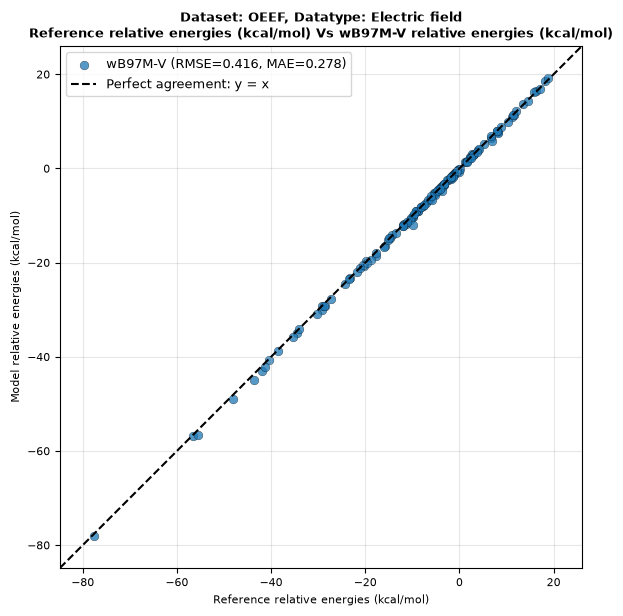

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\OEEF_Reference_vs_wB97M-V_RMSE_MAE.png


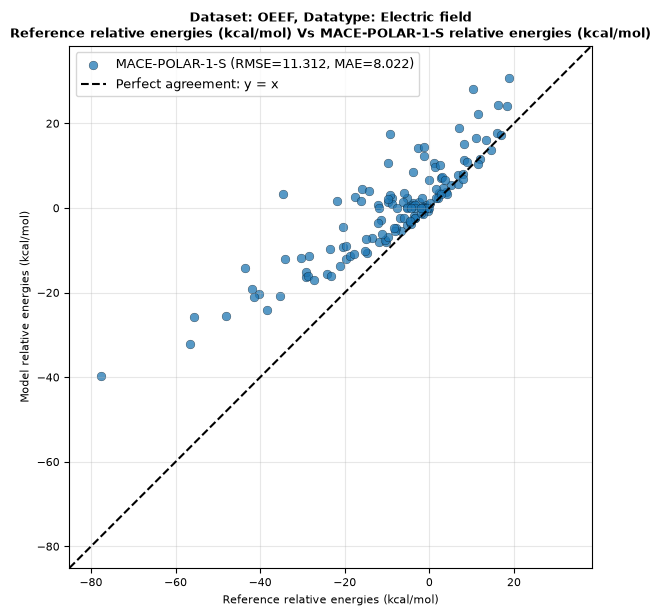

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\OEEF_Reference_vs_mace-polar-1-s_RMSE_MAE.png


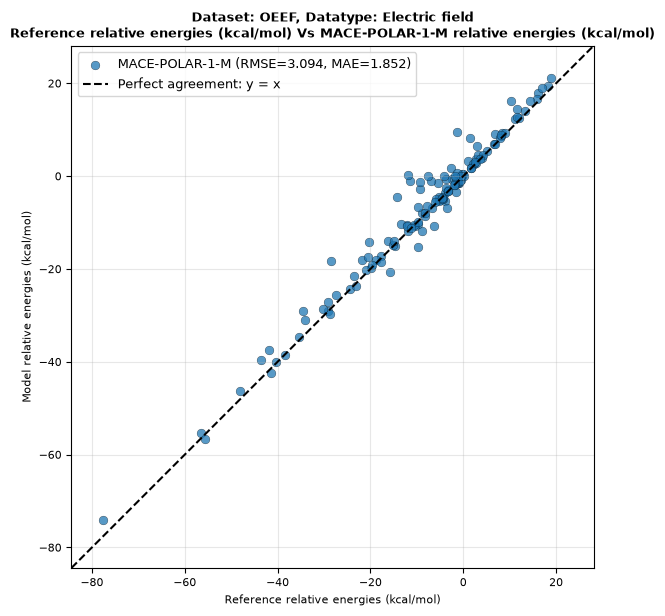

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\OEEF_Reference_vs_mace-polar-1-m_RMSE_MAE.png


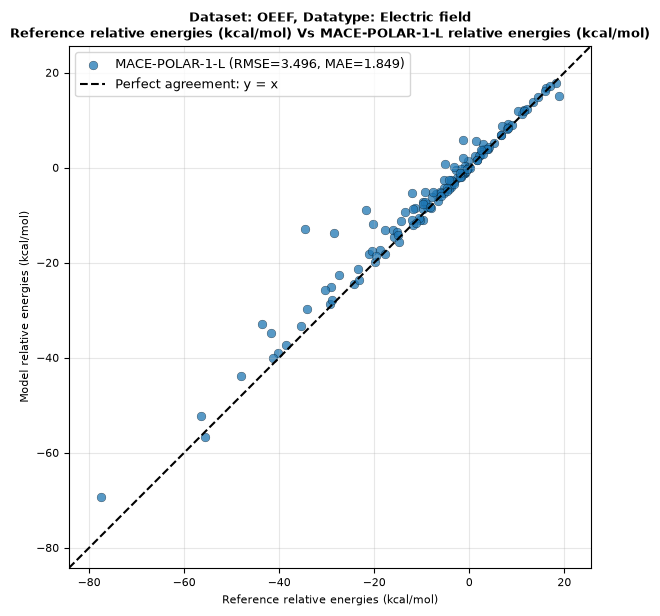

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\OEEF_Reference_vs_mace-polar-1-l_RMSE_MAE.png


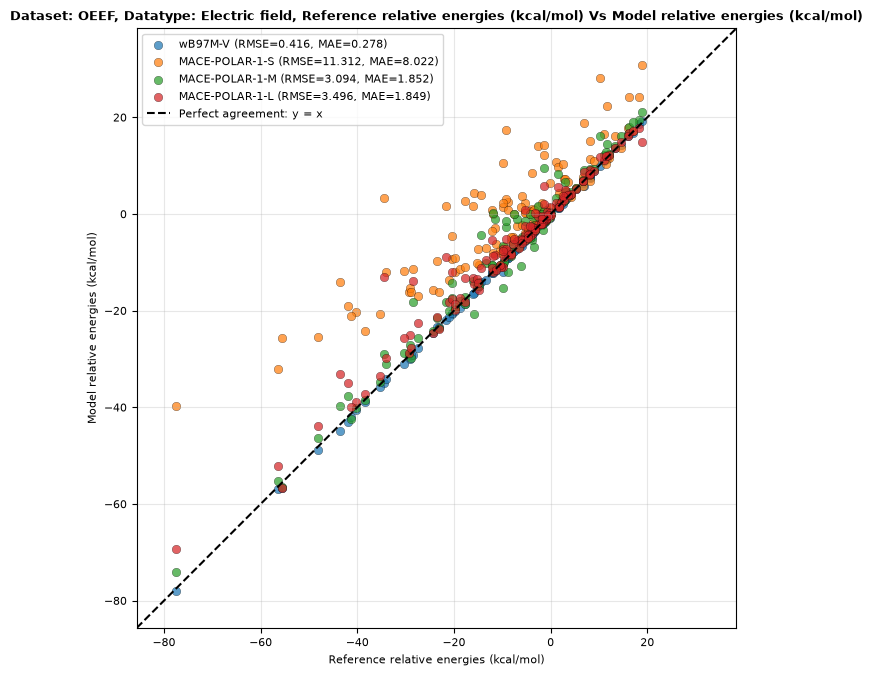

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\OEEF_all_models_RMSE_MAE.png
  Dataset        Datatype           Model      Unit    N       RMSE       MAE  \
0    OEEF  Electric field         wB97M-V  kcal/mol  136   0.416482  0.277940   
1    OEEF  Electric field  MACE-POLAR-1-S  kcal/mol  136  11.312436  8.022000   
2    OEEF  Electric field  MACE-POLAR-1-M  kcal/mol  136   3.093777  1.851934   
3    OEEF  Electric field  MACE-POLAR-1-L  kcal/mol  136   3.495966  1.848600   

   Pearson_r  
0   0.999797  
1   0.879291  
2   0.984871  
3   0.983055  


In [4]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT/"Analysis").exists(): ROOT = ROOT.parent
A, FIG = ROOT/"Analysis", ROOT/"Analysis"/"Figures"
FIG.mkdir(exist_ok=True)

DATASET, DATATYPE, UNIT = "OEEF", "Electric field", "kcal/mol"
df = pd.read_csv(A/"Results_values_with_MACE_POLAR_OEEF_ALL3.csv", index_col=0)

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
LABELS = {"wB97M-V":"wB97M-V", "mace-polar-1-s":"MACE-POLAR-1-S",
          "mace-polar-1-m":"MACE-POLAR-1-M", "mace-polar-1-l":"MACE-POLAR-1-L"}

def met(x, y):
    d = pd.DataFrame({"x":x, "y":y}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    return len(x), np.sqrt(np.mean(e**2)), np.mean(np.abs(e)), np.corrcoef(x,y)[0,1]

def lim(*s):
    v = np.concatenate([pd.to_numeric(x, errors="coerce").dropna().to_numpy(float) for x in s])
    p = 0.07 * (v.max() - v.min())
    return v.min()-p, v.max()+p

rows = []
for m in MODELS:
    n, rmse, mae, r = met(df["Reference"], df[m])
    rows.append({"Dataset":DATASET,"Datatype":DATATYPE,"Model":LABELS[m],"Unit":UNIT,"N":n,"RMSE":rmse,"MAE":mae,"Pearson_r":r})
    lo, hi = lim(df["Reference"], df[m])
    plt.figure(figsize=(6.8,6.2))
    plt.scatter(df["Reference"], df[m], s=40, alpha=0.75, edgecolors="black", linewidths=0.25,
                label=f"{LABELS[m]} (RMSE={rmse:.3f}, MAE={mae:.3f})")
    plt.plot([lo,hi],[lo,hi],"--",color="black",linewidth=1.5,label="Perfect agreement: y = x")
    plt.xlim(lo,hi); plt.ylim(lo,hi); plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Reference relative energies (kcal/mol)")
    plt.ylabel("Model relative energies (kcal/mol)")
    plt.title(f"Dataset: OEEF, Datatype: Electric field\nReference relative energies (kcal/mol) Vs {LABELS[m]} relative energies (kcal/mol)", fontweight="bold")
    plt.grid(alpha=0.3); plt.legend(fontsize=9); plt.tight_layout()
    out = FIG/f"OEEF_Reference_vs_{m}_RMSE_MAE.png"
    plt.savefig(out, dpi=300); plt.show()
    print("Saved:", out)

lo, hi = lim(df["Reference"], *[df[m] for m in MODELS])
plt.figure(figsize=(7.4,6.8))
for m in MODELS:
    n, rmse, mae, r = met(df["Reference"], df[m])
    plt.scatter(df["Reference"], df[m], s=38, alpha=0.72, edgecolors="black", linewidths=0.25,
                label=f"{LABELS[m]} (RMSE={rmse:.3f}, MAE={mae:.3f})")
plt.plot([lo,hi],[lo,hi],"--",color="black",linewidth=1.5,label="Perfect agreement: y = x")
plt.xlim(lo,hi); plt.ylim(lo,hi); plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Reference relative energies (kcal/mol)")
plt.ylabel("Model relative energies (kcal/mol)")
plt.title("Dataset: OEEF, Datatype: Electric field, Reference relative energies (kcal/mol) Vs Model relative energies (kcal/mol)", fontweight="bold")
plt.grid(alpha=0.3); plt.legend(fontsize=8.2); plt.tight_layout()
out = FIG/"OEEF_all_models_RMSE_MAE.png"
plt.savefig(out, dpi=300); plt.show()
print("Saved:", out)

metrics = pd.DataFrame(rows)
metrics.to_csv(A/"OEEF_correlation_plot_metrics_RMSE_MAE.csv", index=False)
print(metrics)

In [5]:
from pathlib import Path
import re, gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# Pol130 only: MACE-POLAR-1-S/M/L
# ============================================================

DATASET, UNIT = "Pol130", "Å³"
MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"

EV_TO_KCAL = 23.06054783
HARTREE_TO_KCAL = 627.50947406
BOHR_TO_ANG = 0.529177
FIELD_AU_TO_VA = 51.4220674763

def root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run from the GSCDB root folder or from GSCDB/Analysis.")

ROOT = root()
A, I, X, Q = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files", ROOT/"qchem_inputs"
FIG = A/"Figures"; FIG.mkdir(exist_ok=True)

mol_out = A/"Molecule_Energies_MACE_POLAR_Pol130_ALL3.csv"
rxn_out = A/"Reaction_Energies_with_MACE_POLAR_Pol130_ALL3.csv"
val_out = A/"Results_values_with_MACE_POLAR_Pol130_ALL3.csv"
err_out = A/"Results_errors_with_MACE_POLAR_Pol130_ALL3.csv"
met_out = A/"Pol130_ALL3_metrics.csv"
log_out = A/"Molecule_Energies_MACE_POLAR_Pol130_ALL3_error_log.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATASET:", DATASET)

# ============================================================
# Helpers
# ============================================================

def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem(qf):
    charge, mult, field = 0, 1, np.zeros(3)

    if not qf.exists():
        return charge, mult, field

    lines = qf.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        s = line.strip().lower()

        if s == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, mult = int(float(p[0])), int(float(p[1]))

        if s == "$multipole_field":
            d = {"X": 0.0, "Y": 0.0, "Z": 0.0}
            j = i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                p = lines[j].split()
                if len(p) == 2 and p[0].upper() in d:
                    d[p[0].upper()] = float(p[1])
                j += 1
            field = np.array([d["X"], d["Y"], d["Z"]], float)

    return charge, mult, field

def field_from_name(mol, mol_step):
    """
    Final fallback only.

    Pol130 field molecules look like:
        Pol130_AlF0+
        Pol130_AlF0-
        Pol130_AlF2+
        Pol130_BeH21+
        Pol130_BeH22-

    The final digit before +/- is the field axis:
        0 -> X
        1 -> Y
        2 -> Z
    """
    m = re.search(r"([012])([+-])$", mol)
    if not m:
        return np.zeros(3)

    f = np.zeros(3)
    axis = int(m.group(1))
    sign = 1.0 if m.group(2) == "+" else -1.0
    f[axis] = sign * float(mol_step)

    return f

def prepare_atoms(mol, mol_step):
    xf, qf = X/f"{mol}.xyz", Q/f"{mol}.in"
    charge, mult, field = read_qchem(qf)

    atoms = read(xf)

    charge = int(float(atoms.info.get("charge", charge)))
    mult = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", mult))))

    # qchem_inputs should contain exact X/Y/Z field. Use name fallback only if qchem has zero.
    if np.allclose(field, 0.0):
        field = field_from_name(mol, mol_step)

    atoms.positions -= atoms.positions.mean(axis=0)
    atoms.info["charge"] = charge
    atoms.info["spin"] = mult
    atoms.info["external_field"] = field * FIELD_AU_TO_VA

    return atoms, charge, mult, field

def mols_from_stoich(st):
    return [p.strip() for p in str(st).split(",")][1::2]

def rxn_energy(st, dfm, col):
    p = [x.strip() for x in str(st).split(",")]
    e_ev = 0.0

    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i+1]
        if mol not in dfm.index or pd.isna(dfm.loc[mol, col]):
            return np.nan
        e_ev += coef * float(dfm.loc[mol, col])

    return e_ev * EV_TO_KCAL

def kcal_to_A3(e_kcal, step):
    return e_kcal / HARTREE_TO_KCAL / (float(step) ** 2) * (BOHR_TO_ANG ** 3)

def metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    er = y - x
    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(er**2)),
        "MAE": np.mean(np.abs(er)),
        "Relative_MAE": np.mean(np.abs(er / x)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

# ============================================================
# Load base GSCDB files
# ============================================================

df_eval = pd.read_csv(I/"DatasetEval.csv", index_col=0)
df_rxn_all = pd.read_csv(A/"Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A/"Results_values.csv", index_col=0)
df_info = pd.read_csv(I/"Datasets.csv", index_col=0)
df_steps = pd.read_csv(I/"FD_stepsize.csv", index_col=0)

ev = df_eval[df_eval["Dataset"] == DATASET].copy()
idx = ev.index

rxn_base = df_rxn_all.loc[idx].copy()
val_base = df_val_all.loc[idx].copy()
steps = df_steps.loc[idx, "fd step"].astype(float)
datatype = df_info.loc[DATASET, "Datatype"]

print("\nDataset:", DATASET)
print("Datatype:", datatype)
print("Rows:", len(ev))
print("Unique FD steps:", sorted(steps.unique()))
print("Existing wB97M-V MAE:", np.mean(np.abs(val_base["wB97M-V"] - val_base["Reference"])))

converted_check = rxn_base["wB97M-V"] / HARTREE_TO_KCAL / (steps ** 2) * (BOHR_TO_ANG ** 3)
print("Max explicit-conversion mismatch for wB97M-V:",
      np.nanmax(np.abs(converted_check - val_base["wB97M-V"])))

# Map each molecule to the FD step of its reaction.
# This is used only as a fallback if qchem_inputs field parsing fails.
mol_step = {}
for rid, row in ev.iterrows():
    for m in mols_from_stoich(row["Stoichiometry"]):
        mol_step.setdefault(m, float(steps.loc[rid]))

all_mols = sorted(mol_step)
print("Unique Pol130 molecules:", len(all_mols))

# ============================================================
# Build metadata and field checks
# ============================================================

meta = []
for m in all_mols:
    at, ch, sp, f = prepare_atoms(m, mol_step[m])
    meta.append({
        "Molecule": m,
        "charge": ch,
        "multiplicity": sp,
        "num_atoms": len(at),
        "fd_step": mol_step[m],
        "field_au_x": f[0],
        "field_au_y": f[1],
        "field_au_z": f[2],
        "field_VA_x": f[0] * FIELD_AU_TO_VA,
        "field_VA_y": f[1] * FIELD_AU_TO_VA,
        "field_VA_z": f[2] * FIELD_AU_TO_VA,
    })

df_mol = pd.DataFrame(meta).set_index("Molecule")

print("\nField value counts:")
print(df_mol[["field_au_x", "field_au_y", "field_au_z"]].value_counts().head(30))

base_mask = ~df_mol.index.to_series().str.contains(r"[012][+-]$", regex=True)
bad_base = df_mol.loc[base_mask, ["field_au_x", "field_au_y", "field_au_z"]].abs().sum(axis=1)

if (bad_base > 1e-15).any():
    print(df_mol.loc[bad_base[bad_base > 1e-15].index, ["field_au_x", "field_au_y", "field_au_z"]])
    raise ValueError("Some zero-field Pol130 base molecules have non-zero field. Stop.")

if np.allclose(df_mol[["field_au_x", "field_au_y", "field_au_z"]].to_numpy(), 0.0):
    raise ValueError("All Pol130 fields are zero. Stop.")

# ============================================================
# MACE-POLAR molecule energies
# ============================================================

errs = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)
    df_mol[col] = np.nan

    for n, m in enumerate(tqdm(all_mols, desc=f"{DATASET}:{col}"), start=1):
        try:
            at, ch, sp, f = prepare_atoms(m, mol_step[m])
            reset_calc(calc)
            at.calc = calc
            df_mol.loc[m, col] = float(at.get_potential_energy())

        except Exception as exc:
            errs.append({"Molecule": m, "Model": col, "Error": repr(exc)})

        if n % 10 == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errs).to_csv(log_out, index=False)
df_mol.to_csv(mol_out)

print("\nSaved molecule energies:")
print(mol_out)

print("\nMissing molecule energies:")
print(df_mol[list(MODELS)].isna().sum())

# ============================================================
# Reaction energies in kcal/mol
# ============================================================

df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Pol130 reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy check:")
for col in MODELS:
    print(
        col,
        "| zeros:", np.isclose(df_rxn[col], 0.0).sum(),
        "| unique:", df_rxn[col].nunique(),
        "| min/max:", df_rxn[col].min(), df_rxn[col].max(),
    )

# ============================================================
# Convert Pol130 to polarizabilities using VARIABLE step sizes
# ============================================================

df_val = val_base.copy()

for col in MODELS:
    df_val[col] = [
        kcal_to_A3(df_rxn.loc[rid, col], steps.loc[rid]) if pd.notna(df_rxn.loc[rid, col]) else np.nan
        for rid in df_rxn.index
    ]

df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")

df_err.to_csv(err_out)

# ============================================================
# Metrics
# ============================================================

rows = []
for col in ["wB97M-V", *MODELS.keys()]:
    row = metrics(df_val["Reference"], df_val[col])
    row.update({"Dataset": DATASET, "Datatype": datatype, "Model": col, "Unit": UNIT})
    rows.append(row)

df_met = pd.DataFrame(rows)
df_met = df_met[["Dataset", "Datatype", "Model", "Unit", "N", "RMSE", "MAE", "Relative_MAE", "Pearson_r"]]
df_met.to_csv(met_out, index=False)

print("\nMetric table:")
print(df_met)

print("\nSaved files:")
for f in [mol_out, rxn_out, val_out, err_out, met_out, log_out]:
    print(f)

ROOT: c:\Users\91988\GSCDB Benchmarking
DEVICE: cpu
DATASET: Pol130

Dataset: Pol130
Datatype: Electric field
Rows: 296
Unique FD steps: [np.float64(0.001), np.float64(0.003), np.float64(0.01)]
Existing wB97M-V MAE: 0.2815120212334237
Max explicit-conversion mismatch for wB97M-V: 3.552713678800501e-15
Unique Pol130 molecules: 722

Field value counts:
field_au_x  field_au_y  field_au_z
 0.000       0.000       0.000        130
 0.010       0.000       0.000        113
-0.010       0.000       0.000        113
 0.000       0.000       0.010        111
                        -0.010        111
             0.010       0.000         53
            -0.010       0.000         53
 0.001       0.000       0.000          9
-0.001       0.000       0.000          9
 0.000       0.000       0.001          8
                        -0.001          8
             0.001       0.000          1
            -0.001       0.000          1
 0.003       0.000       0.000          1
-0.003       0.000      

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Pol130:mace-polar-1-s: 100%|██████████| 722/722 [02:27<00:00,  4.91it/s]



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Pol130:mace-polar-1-m: 100%|██████████| 722/722 [05:54<00:00,  2.04it/s]



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Pol130:mace-polar-1-l: 100%|██████████| 722/722 [16:02<00:00,  1.33s/it]



Saved molecule energies:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Pol130_ALL3.csv

Missing molecule energies:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Pol130 reaction energies: 100%|██████████| 296/296 [00:01<00:00, 285.68it/s]



Reaction-energy check:
mace-polar-1-s | zeros: 97 | unique: 200 | min/max: -0.8567692779435089 0.014217562090447671
mace-polar-1-m | zeros: 97 | unique: 200 | min/max: -1.20550273725463 4.130008249977532
mace-polar-1-l | zeros: 97 | unique: 200 | min/max: -2.9019598463469904 3.260908580234888

Metric table:
  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0  Pol130  Electric field         wB97M-V   Å³  296  0.799282  0.281512   
1  Pol130  Electric field  mace-polar-1-s   Å³  296  8.611687  5.150170   
2  Pol130  Electric field  mace-polar-1-m   Å³  296  7.638158  3.256214   
3  Pol130  Electric field  mace-polar-1-l   Å³  296  7.807098  3.317789   

   Relative_MAE  Pearson_r  
0      0.048087   0.997198  
1      1.049763  -0.066693  
2      0.612135   0.080857  
3      0.621654  -0.009703  

Saved files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Pol130_ALL3.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_M

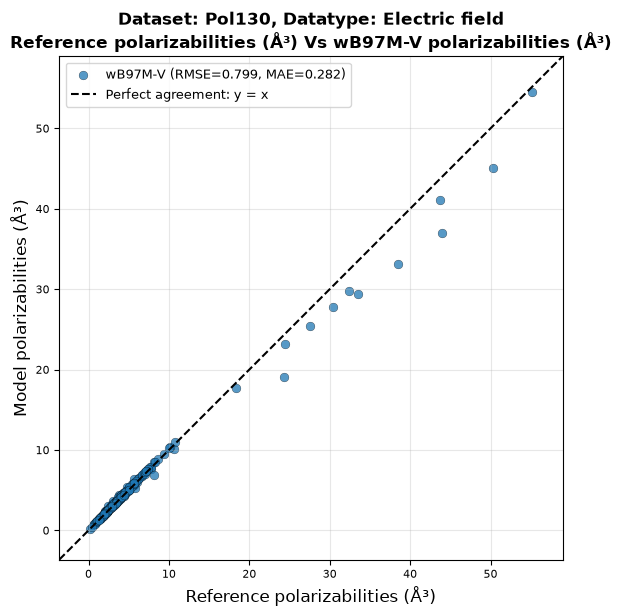

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Pol130_Reference_vs_wB97M-V_RMSE_MAE.png


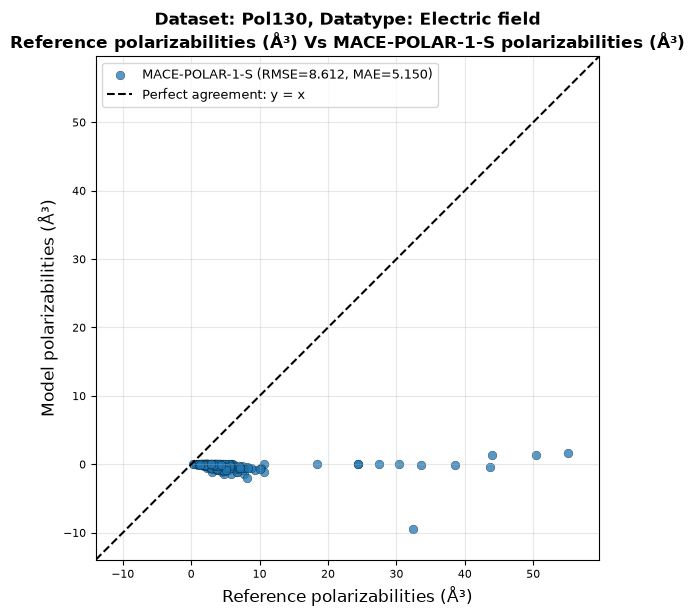

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Pol130_Reference_vs_mace-polar-1-s_RMSE_MAE.png


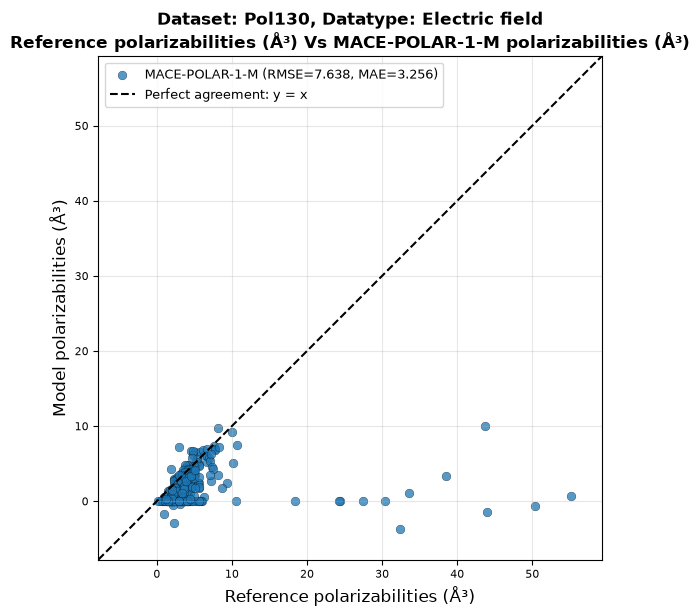

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Pol130_Reference_vs_mace-polar-1-m_RMSE_MAE.png


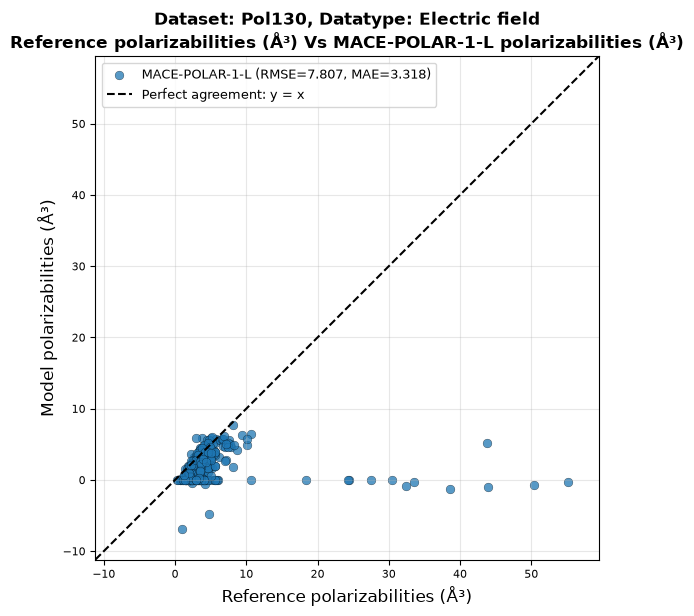

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Pol130_Reference_vs_mace-polar-1-l_RMSE_MAE.png


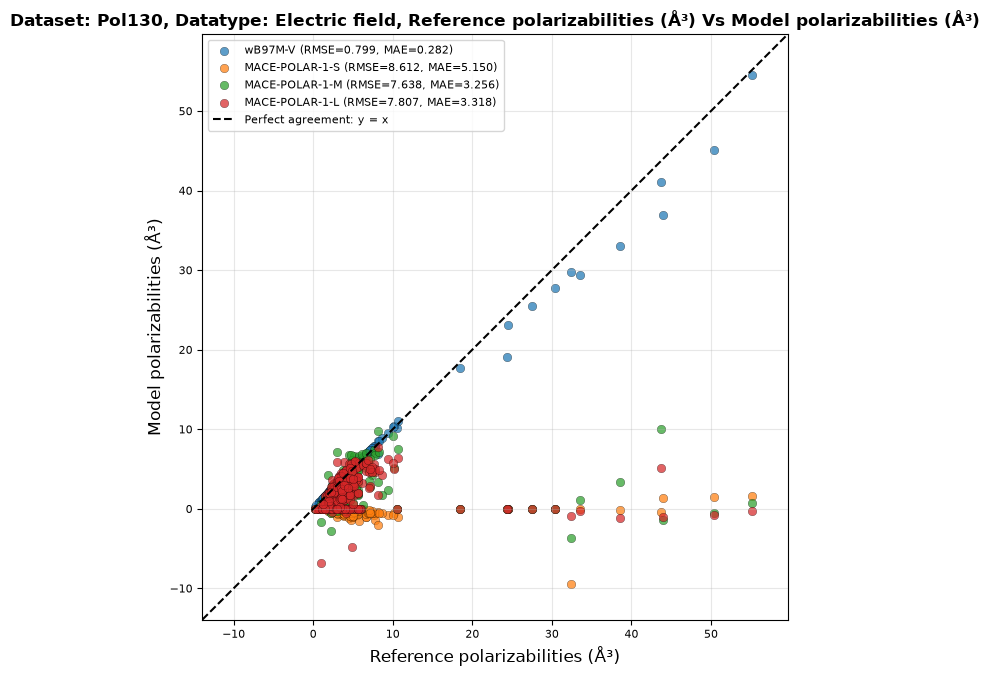

Saved: c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Pol130_all_models_RMSE_MAE.png

Saved metrics:
c:\Users\91988\GSCDB Benchmarking\Analysis\Pol130_correlation_plot_metrics_RMSE_MAE.csv
  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0  Pol130  Electric field         wB97M-V   Å³  296  0.799282  0.281512   
1  Pol130  Electric field  MACE-POLAR-1-S   Å³  296  8.611687  5.150170   
2  Pol130  Electric field  MACE-POLAR-1-M   Å³  296  7.638158  3.256214   
3  Pol130  Electric field  MACE-POLAR-1-L   Å³  296  7.807098  3.317789   

   Relative_MAE  Pearson_r  
0      0.048087   0.997198  
1      1.049763  -0.066693  
2      0.612135   0.080857  
3      0.621654  -0.009703  


In [6]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT/"Analysis").exists():
    ROOT = ROOT.parent

A = ROOT/"Analysis"
FIG = A/"Figures"
FIG.mkdir(exist_ok=True)

DATASET, DATATYPE, UNIT = "Pol130", "Electric field", "Å³"

df = pd.read_csv(A/"Results_values_with_MACE_POLAR_Pol130_ALL3.csv", index_col=0)

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

def met(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e**2)),
        "MAE": np.mean(np.abs(e)),
        "Relative_MAE": np.mean(np.abs(e / x)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def lim(*series):
    values = np.concatenate([
        pd.to_numeric(s, errors="coerce").dropna().to_numpy(float)
        for s in series
    ])
    pad = 0.07 * (values.max() - values.min())
    return values.min() - pad, values.max() + pad

rows = []

# ============================================================
# Individual model plots
# ============================================================

for m in MODELS:
    mm = met(df["Reference"], df[m])
    rows.append({
        "Dataset": DATASET,
        "Datatype": DATATYPE,
        "Model": LABELS[m],
        "Unit": UNIT,
        **mm,
    })

    lo, hi = lim(df["Reference"], df[m])

    plt.figure(figsize=(6.8, 6.2))

    plt.scatter(
        df["Reference"],
        df[m],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{LABELS[m]} (RMSE={mm['RMSE']:.3f}, MAE={mm['MAE']:.3f})",
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
    plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

    plt.title(
        f"Dataset: Pol130, Datatype: Electric field\n"
        f"Reference polarizabilities (Å³) Vs {LABELS[m]} polarizabilities (Å³)",
        fontsize=12,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()

    out = FIG/f"Pol130_Reference_vs_{m}_RMSE_MAE.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

# ============================================================
# Extra combined all-model plot
# ============================================================

lo, hi = lim(df["Reference"], *[df[m] for m in MODELS])

plt.figure(figsize=(7.4, 6.8))

for m in MODELS:
    mm = met(df["Reference"], df[m])

    plt.scatter(
        df["Reference"],
        df[m],
        s=38,
        alpha=0.72,
        edgecolors="black",
        linewidths=0.25,
        label=f"{LABELS[m]} (RMSE={mm['RMSE']:.3f}, MAE={mm['MAE']:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference polarizabilities (Å³)", fontsize=12)
plt.ylabel("Model polarizabilities (Å³)", fontsize=12)

plt.title(
    "Dataset: Pol130, Datatype: Electric field, "
    "Reference polarizabilities (Å³) Vs Model polarizabilities (Å³)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8.2)
plt.tight_layout()

out = FIG/"Pol130_all_models_RMSE_MAE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

metrics = pd.DataFrame(rows)
metrics_out = A/"Pol130_correlation_plot_metrics_RMSE_MAE.csv"
metrics.to_csv(metrics_out, index=False)

print("\nSaved metrics:")
print(metrics_out)
print(metrics)